# Reto: Tercer Avance — Spaceship Titanic

## Preparación de datos (pipeline heredado del Primer Avance)

## 1. Carga y comprensión del dataset
*   carga train.csv y test.csv de Spaceship Titanic desde Kaggle.
*   Inspecciona shape, tipos de variables, y primeras filas.
*   Identifica cuál es la variable target y confirma que tipo de problema es.

Nota: Kaggle ya provee train y test separados, no necesitas hacer split. Todo tu trabajo de preparación ocurre sobre train.csv.

In [2]:
# Carga del dataset crudo desde una ruta relativa local (en lugar de kagglehub),
# siguiendo el mismo criterio de portabilidad adoptado en el Segundo Avance.
# Coloca train.csv y test.csv de la competencia dentro de una carpeta 'data/' junto a este notebook.
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import chi2_contingency


df_train = pd.read_csv('data/train.csv')
df_test = pd.read_csv('data/test.csv')

print(f"Tamaño dataframe train {df_train.shape}")
print(f"Tamaño dataframe test {df_test.shape}")
print(f"Tipos de variables train: \n {df_train.dtypes}")
print(f"Primeras filas train: \n {df_train.head()}")
print(f"Valores únicos por columna train: \n {df_train.nunique()}")

Tamaño dataframe train (8693, 14)
Tamaño dataframe test (4277, 13)
Tipos de variables train: 
 PassengerId         str
HomePlanet          str
CryoSleep        object
Cabin               str
Destination         str
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name                str
Transported        bool
dtype: object
Primeras filas train: 
   PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0 

En esta primera parte se cargaron tanto el dataset de entrenamiento como el de prueba. El dataframe de entrenamiento cuenta con 14 columnas (PassengerId, HomePlanet, CryoSleep, Cabin, Destination, Age, VIP, RoomService, FoodCourt, ShoppingMall, Spa, VRDeck, Name, Transported) y 8693 filas, correspondientes a cada uno de los registros. El dataframe de prueba cuenta con las mismas columnas, excepto Transported, que es nuestra variable objetivo.
Este es un problema de clasificación binaria, es decir, se busca predecir si la persona fue transportada (True) o no (False). Esto se sabe tanto por la descripción del problema como por la ausencia de dicha columna en el dataframe de prueba.
En esta observación inicial se identificaron algunos detalles relevantes:
- Pandas reconoció correctamente el tipo de dato de Transported, pero interpretó CryoSleep y VIP como tipo object, lo que sugiere la presencia de datos faltantes o valores NaN en dichas columnas.
- Al analizar las primeras columnas, en conjunto con la explicación proporcionada por Kaggle, se encontró un patrón entre PassengerID y Cabin: de acuerdo con el identificador de grupo presente en PassengerID, se puede inferir (mas no concluir) que los integrantes de un mismo grupo suelen compartir cabina.
- Se encontraron 8693 valores de PassengerID, cifra que coincide exactamente con el número de filas del dataframe.
- Adicionalmente, se identificaron solo 8473 valores únicos de Name, lo que indica la existencia de valores repetidos (personas distintas con el mismo nombre) y/o valores NaN.
- Finalmente, se buscaron filas duplicadas, no encontrándose ninguna; esto se concluyó a partir de la ausencia de valores duplicados en PassengerID.

##2. Análisis exploratorio (EDA)

* Reporta el porcentaje de faltantes por columna y clasifica cada uno como faltante informativo o faltante real, justificando tu clasificación con el contexto del problema (usa la descripción del dataset en Kaggle).
* Analiza la distribución de variables numéricas: histogramas, skewness, presencia de outliers (Tukey/IQR).
* Analiza variables categóricas: cardinalidad, distribución de categorías, detección de variables con desbalance extremo.
* Analiza la relación de cada variable con el target: usa crosstabs para categóricas y boxplots para numéricas. Este análisis es la base de tu selección de variables, sin él no puedes justificar qué entra y qué no.

Porcentaje de datos faltantes: 
 PassengerId     0.000000
HomePlanet      2.312205
CryoSleep       2.496261
Cabin           2.289198
Destination     2.093639
Age             2.059128
VIP             2.335212
RoomService     2.082135
FoodCourt       2.105142
ShoppingMall    2.392730
Spa             2.105142
VRDeck          2.162660
Name            2.300702
Transported     0.000000
dtype: float64
---------- Histogramas ---------


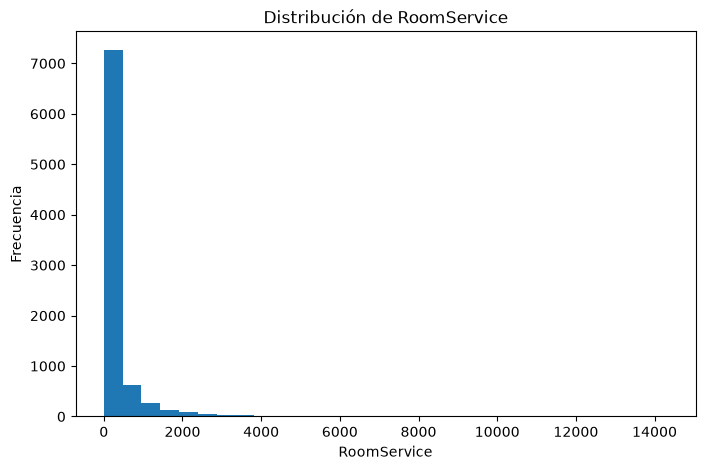

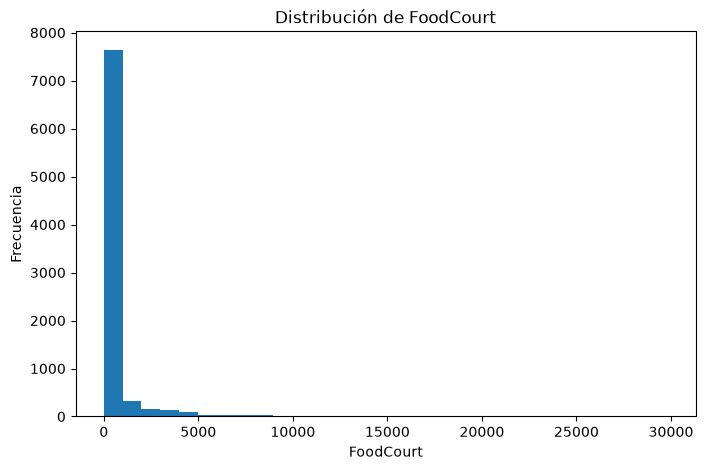

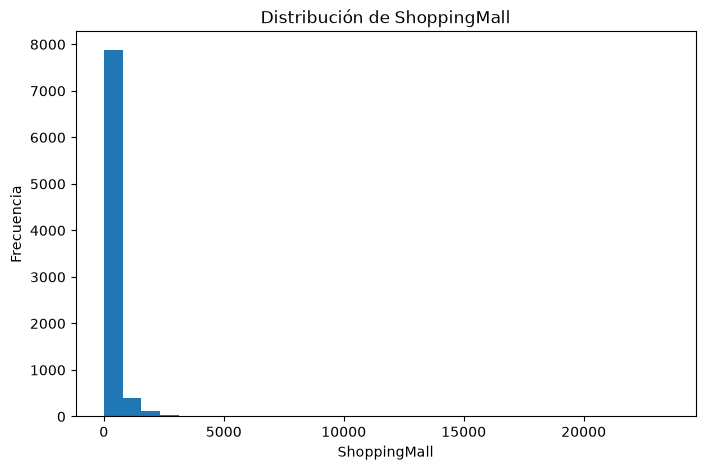

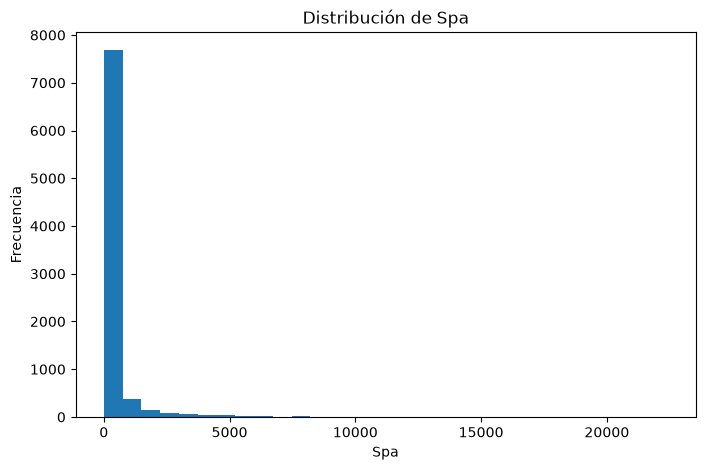

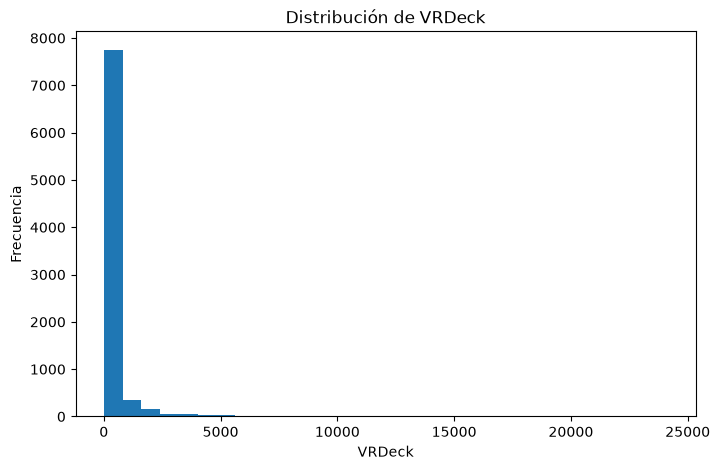

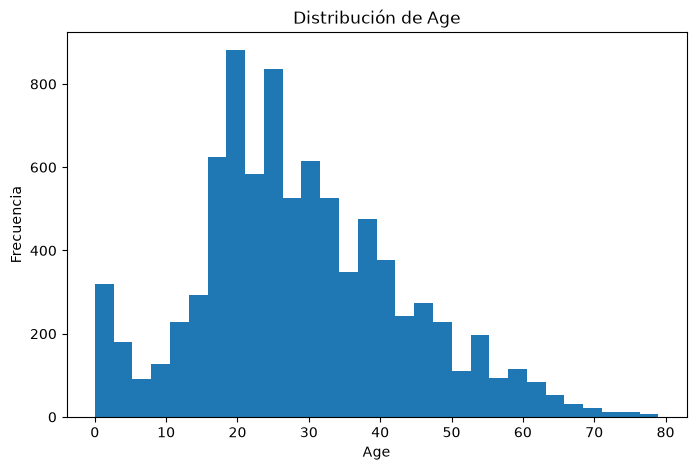

---------- Skewness ---------
RoomService      6.333014
FoodCourt        7.102228
ShoppingMall    12.627562
Spa              7.636020
VRDeck           7.819732
Age              0.419097
dtype: float64
---------- Outliers ---------
RoomService: 1861 outliers
FoodCourt: 1823 outliers
ShoppingMall: 1829 outliers
Spa: 1788 outliers
VRDeck: 1809 outliers
Age: 77 outliers
---------- Cardinalidad ---------
CryoSleep
False    0.641694
True     0.358306
Name: proportion, dtype: float64
VIP
False    0.976561
True     0.023439
Name: proportion, dtype: float64
HomePlanet
Earth     0.541922
Europa    0.250942
Mars      0.207136
Name: proportion, dtype: float64
Destination
TRAPPIST-1e      0.694983
55 Cancri e      0.211491
PSO J318.5-22    0.093526
Name: proportion, dtype: float64
Cabin_Deck
F    0.328938
G    0.301271
E    0.103132
B    0.091712
C    0.087944
D    0.056275
A    0.030139
T    0.000589
Name: proportion, dtype: float64
Cabin_Num
82      0.003296
19      0.002590
86      0.002590
56  

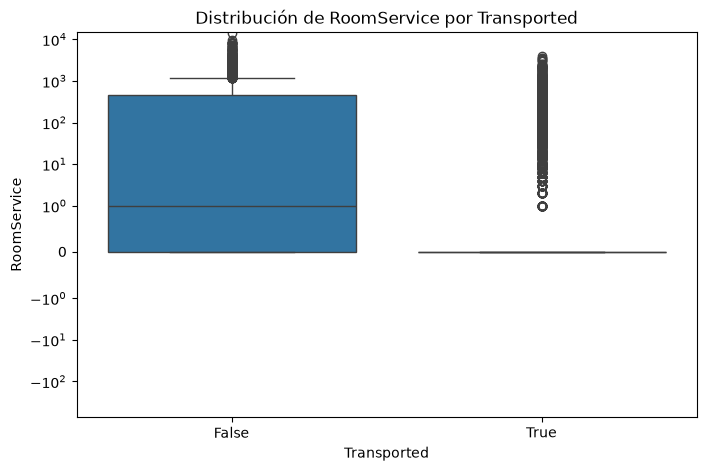

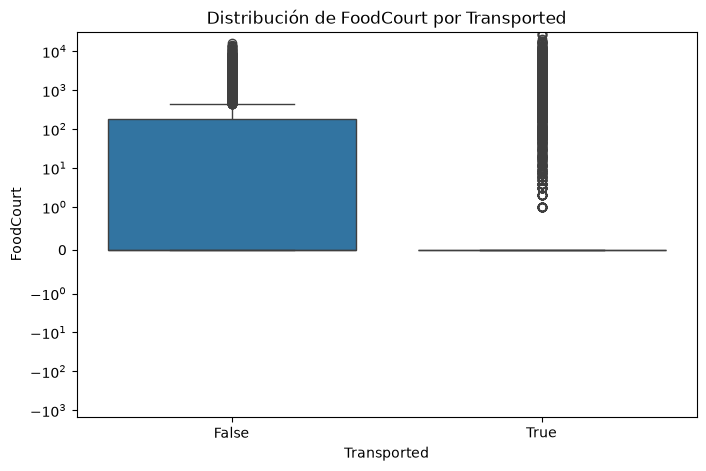

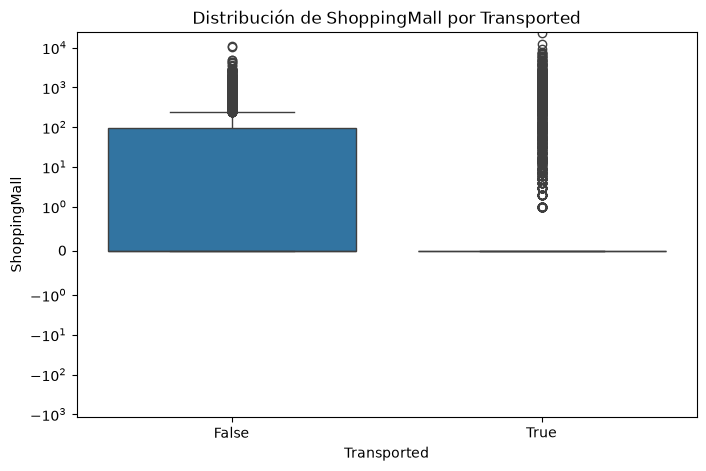

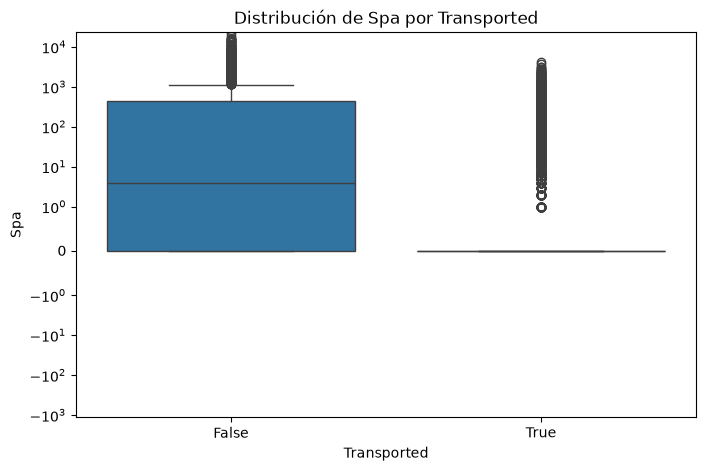

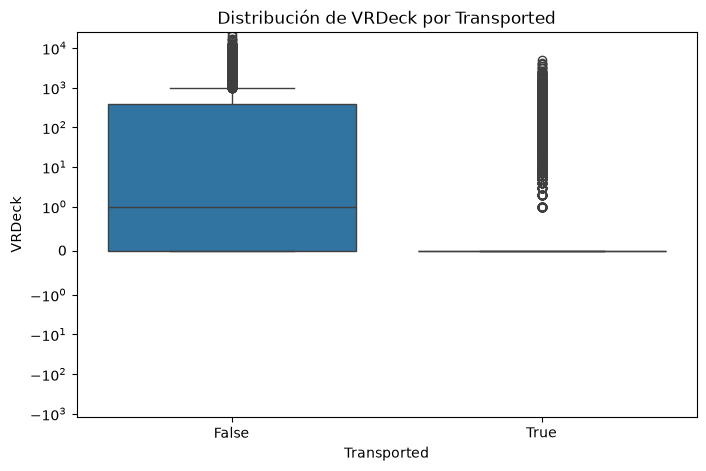


--- RoomService ---
              count        mean         std  min  25%   50%    75%      max
Transported                                                                
False        3569.0  448.336229  922.314810  0.0  0.0  17.0  593.0  14327.0
True         1759.0  150.920978  410.463092  0.0  0.0   0.0   59.0   3992.0

--- FoodCourt ---
              count         mean          std  min  25%   50%      75%  \
Transported                                                              
False        3576.0   442.368009  1287.071661  0.0  0.0   3.0   287.25   
True         1753.0  1265.083856  2823.836591  0.0  0.0  39.0  1065.00   

                 max  
Transported           
False        16856.0  
True         29813.0  

--- ShoppingMall ---
              count       mean          std  min  25%  50%    75%      max
Transported                                                               
False        3578.0  192.31526   486.931679  0.0  0.0  2.0  155.0  10705.0
True         1757.0 

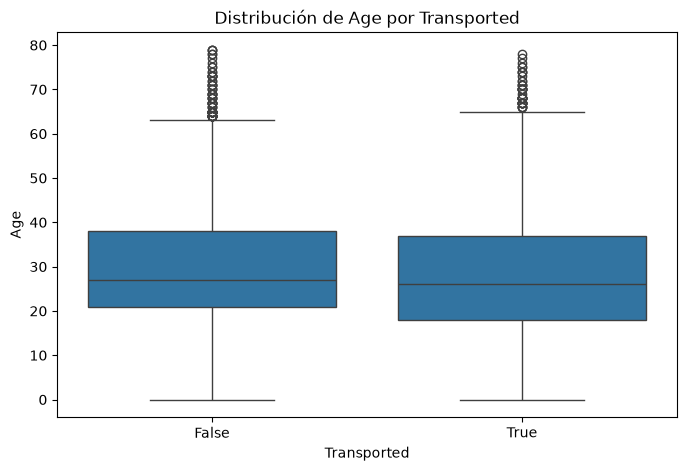

In [3]:
porcentaje_faltantes = (df_train.isna().sum() / len(df_train)) * 100
print(f"Porcentaje de datos faltantes: \n {porcentaje_faltantes}")


numericas = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck", "Age"]


print("---------- Histogramas ---------")
for col in numericas:
    plt.figure(figsize=(8, 5))
    plt.hist(df_train[col].dropna(), bins=30)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

print("---------- Skewness ---------")
print(df_train[numericas].skew())

print("---------- Outliers ---------")
for col in numericas:
    Q1 = df_train[col].quantile(0.25)
    Q3 = df_train[col].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df_train[
        (df_train[col] < limite_inferior) |
        (df_train[col] > limite_superior)
    ]

    print(f'{col}: {len(outliers)} outliers')

print("---------- Cardinalidad ---------")

df_train[['Cabin_Deck', 'Cabin_Num', 'Cabin_Side']] = df_train['Cabin'].str.split('/', expand=True)

print(df_train['CryoSleep'].value_counts(normalize=True))
print(df_train['VIP'].value_counts(normalize=True))
print(df_train['HomePlanet'].value_counts(normalize=True))
print(df_train['Destination'].value_counts(normalize=True))
print(df_train['Cabin_Deck'].value_counts(normalize=True))
print(df_train['Cabin_Num'].value_counts(normalize=True))
print(df_train['Cabin_Side'].value_counts(normalize=True))

print("---------- Crosstabs ---------")

categoricas = ["HomePlanet", "CryoSleep", "Destination", "VIP", "Cabin_Deck", "Cabin_Side"]

for col in categoricas:
    print(pd.crosstab(df_train[col], df_train['Transported'], normalize='index'))

print("---------- Boxplots ---------")

numericas = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

for col in numericas:

    plt.figure(figsize=(8, 5))

    sns.boxplot(x='Transported', y=col, data=df_train)

    plt.yscale('symlog', linthresh=1)

    plt.title(f'Distribución de {col} por Transported')
    plt.show()

for col in ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]:
    print(f"\n--- {col} ---")
    print(
        df_train[df_train['CryoSleep'] == False]
        .groupby('Transported')[col]
        .describe()
    )

plt.figure(figsize=(8, 5))

sns.boxplot(x='Transported', y="Age", data=df_train)

plt.title(f'Distribución de Age por Transported')
plt.show()





Primero se analizó la cantidad de valores faltantes por columna para conocer la calidad inicial de los datos y determinar si existían variables con un problema importante de missing values. Se encontró que los porcentajes son bastante uniformes, aproximadamente entre 2.1% y 2.5%, por lo que no existe una columna con una proporción de faltantes especialmente elevada.

Posteriormente se analizaron las variables numéricas mediante histogramas y skewness para conocer la forma de sus distribuciones. Las cinco variables de gasto presentan un sesgo positivo muy elevado, mientras que Age tiene una distribución mucho más cercana a la normalidad. Se utilizó el método de Tukey/IQR para identificar posibles outliers y se encontró una gran cantidad en las variables de gasto. Sin embargo, no se decidió eliminarlos ya que los valores extremos pueden representar gastos reales de los pasajeros y, por lo tanto, contener información predictiva.

Para las variables categoricas, se revisó su cardinalidad y distribución para conocer cuántas categorías existen y detectar posibles problemas de desbalance. La mayoría presenta una cardinalidad baja y manejable, mientras que Cabin_Num tiene una cardinalidad mucho mayor. VIP destaca como el único caso de desbalance extremo, ya que aproximadamente el 97.7% de los pasajeros no son VIP. También se descompuso Cabin en Cabin_Deck, Cabin_Num y Cabin_Side, ya que la variable original contiene tres componentes que pueden representar información diferente. Cabin_Deck y Cabin_Side se tratarán como variables categóricas, mientras que Cabin_Num se conservará como numérica para evaluar posteriormente si aporta información predictiva.

Después se utilizaron crosstabs para comprobar si las variables categóricas presentaban alguna relación con Transported. Cryosleep mostró la diferencia más marcada, con 81.8% de pasajeros transportados cuando CryoSleep=True frente al 32.9% cuando es False. Homeplanet también mostró diferencias relevantes, especialmente entre Europa y Earth. Destination, Cabin_Deck y Cabin_Side presentaron asociaciones más moderadas, por lo que su utilidad predictiva queda pendiente de confirmarse durante el modelado.

Finalmente se utilizaron boxplots para comparar las variables numéricas con Transported. Age no mostró una relación aparente, ya que las medianas y rangos intercuartílicos fueron muy similares entre ambos grupos. En cambio, las variables de gasto mostraron diferencias claras. Para comprobar si estas diferencias eran simplemente consecuencia de CryoSleep, se repitió el análisis únicamente con pasajeros que tenian CryoSleep=False. Las diferencias persistieron, indicando que las variables de gasto contienen información adicional a CryoSleep. Además RoomService, Spa y VRDeck mostraron una relación inversa con transported, mientras que FoodCourt y ShoppingMall mostraron una relación positiva. La razón de esta dirección opuesta entre grupos queda como una hipótesis abierta para etapas posteriores.
Con este análisis se obtuvo una visión suficiente de la estructura, calidad y relaciones principales del dataset para comenzar la parte 3, manteniendo inicialmente las variables de gasto y las variables derivadas de Cabin. Las principales decisiones de transformación, tratamiento de faltantes y selección definitiva de variables se validarán posteriormente mediante el pipeline y desempeño del modelo.



## 3. Selección y descarte de variables

* Define qué variables incluirás en el pipeline y cuáles descartarás.
* Cada decisión debe estar justificada con evidencia del EDA anterior: porcentaje de faltantes, desbalance extremo, relación con el target, cardinalidad, o redundancia. No se acepta descartar o incluir variables sin argumento.
* Para variables con desbalance extremo, evalúa si binarizar (HasPool, HasCabin, etc.) preserva señales útiles antes de descartarlas.

**Variables a descartar**
1. PassengerId: se eliminará el identificador de cada pasajero debido a que es un indicador único y por lo mismo no aporta valor predictivo por si mismo. Sin embargo se extraerá el grupo del Id y medidas derivadas de él que si son útiles.
2. Name: Se eliminará por las mismas razones que PassengerId, es un indicador único que no aportará al modelo.
3. Cabin: Se eliminará debido a su altísima cardinalidad de 6560 valores, además de que previamente ya extrajimos sus componentes por lo que la columna original es redundante y puede ser descartada.
4. VIP: Tiene un desbalance extremo y ya es una variable binaria, el 97.7% en false, por lo que existe el riesgo de que le añada ruido al modelo. El crosstab no mostró diferencias significativas en el caso negativo; mientras que en el caso positivo, aunque si mostró una diferencia de 12 puntos, debido a que son tan pocos registros no es posible determinar que sea un patron real.

**Variables a incluir**
1. HomePlanet:
De acuerdo a los datos del crosstab existe una difernecia notable entre las categorias Earth 42.4% transportado, Europa 65.9%, Mars 52.3%. La cardinalidad es baja por lo que son de fácil codificación de 3 categorías además los faltantes son manejables (2%) y se puede hacer imputación con moda o categoría "Missing".

2. CryoSleep:
Es la variable con mayor poder discriminante de todo el dataset con 81.8% transportados cuando True vs 32.9% cuando False (49 puntos de diferencia). Se incluye directamente.

3. Cabin_Side:
Son solo 2 valores (P: 45.1% transportado, S: 55.5%), existe una diferencia moderada y hay suficientes muestras de ambos lados.

4. Destination:
También tiene una diferencia moderada en transportados de acuerdo a su destino. Por su cardinalidad baja no complejiza tanto el análisis, todas las categorías tienen suficientes muestras para generalizar.

5. Group, GroupSize y IsAlone: Group se extraerá del PassengerId para revisar de que grupo era parte cada persona, a su vez se calculará el tamaño de grupo en el que viaja cada pasajero y si este grupo es de una (1) persona se añadirá como verdadero en la columna binaria IsAlone que indica si viaja solo el pasajero.


**Variables a transformar**
1. Cabin Deck: El deck T tiene muy pocas muestras, para evitar que se aprenda una relacion erronea basada en 5 datos se agregará al deck D, donde esta cantidad pequeña no afectará significativamente el comportamiento del deck D completo.
2. Cabin num: Pasar de variable categórica a una numérica para no tratar con una cardinalidad muy alta, además de que dicho número podría ser un indicador de la ubicación física en la nave.
3. RoomService, FoodCourt, ShoppingMall, Spa, VRDeck: Todas las variables de gasto tienen un sesgo positivo muy alto, por lo que se reescalarán logarítmicamente para reducir dicho sesgo sin perder la información de los valores extremos. Adicionalmente, se sumarán todos los gastos en una variable continua llamada *TotalSpent*, la cual también será reescalada logarítmicamente, y se creará una variable binaria llamada *HasSpent* que indicará si el pasajero realizó algún gasto durante su estadía o no. Ambas variables convivirán, ya que capturan información distinta: *HasSpent* refleja el efecto de umbral (si gastó o no, relacionado con CryoSleep), mientras que *TotalSpent* conserva la magnitud del gasto.
4. Age: La variable age se mantendrá sin cambios, pero además se añadirá una columna para que cada persona menor a 15 años sea considerada como un niño para que el modelo capture ese efecto.


In [4]:
df_train['Cabin_Deck'].value_counts()

Cabin_Deck
F    2794
G    2559
E     876
B     779
C     747
D     478
A     256
T       5
Name: count, dtype: int64

In [5]:
# Extraer el grupo y si viaja solo
df_train["Group"] = df_train["PassengerId"].str.split("_").str[0]
df_train["GroupSize"] = df_train.groupby("Group")["Group"].transform("count")
df_train["IsAlone"] = (df_train["GroupSize"] == 1).astype(int)

#borrar las columnas determinadas
df_train.drop(columns=["PassengerId", "Name", "Cabin", "VIP"], inplace=True)

#sumar los gastos para crear la columna de gasto total y si ha gastado
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
df_train["TotalSpent"] = df_train[spend_cols].sum(axis=1, skipna=True)
df_train["HasSpent"] = (df_train["TotalSpent"] > 0).astype(int)

#añadir columna binaria para saber si el pasajero es un niño
df_train["IsChild"] = (df_train["Age"] < 15).astype(int)

In [6]:
df_train.head()

,HomePlanet,CryoSleep,Destination,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Cabin_Deck,Cabin_Num,Cabin_Side,Group,GroupSize,IsAlone,TotalSpent,HasSpent,IsChild
0,Europa,False,TRAPPIST-1e,39.0,0.0,0.0,0.0,0.0,0.0,False,B,0,P,0001,1,1,0.0,0,0
1,Earth,False,TRAPPIST-1e,24.0,109.0,9.0,25.0,549.0,44.0,True,F,0,S,0002,1,1,736.0,1,0
2,Europa,False,TRAPPIST-1e,58.0,43.0,3576.0,0.0,6715.0,49.0,False,A,0,S,0003,2,0,10383.0,1,0
3,Europa,False,TRAPPIST-1e,33.0,0.0,1283.0,371.0,3329.0,193.0,False,A,0,S,0003,2,0,5176.0,1,0
4,Earth,False,TRAPPIST-1e,16.0,303.0,70.0,151.0,565.0,2.0,True,F,1,S,0004,1,1,1091.0,1,0


In [7]:
print(df_train.shape)
print(df_train[["TotalSpent", "HasSpent", "IsChild"]].sample())

(8693, 19)
      TotalSpent  HasSpent  IsChild
6393      5107.0         1        0


## 4. Manejo de faltantes

* Aplica la estrategia de imputación correspondiente según la clasificación del paso 2.
* Justifica la elección de estrategia para cada variable. No uses la misma estrategia para todo sin argumentar.


In [8]:
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

# CryoSleep (categórica, 2.5% faltante): Faltante informativo
gasto_conocido = df_train[spend_cols].sum(axis=1, skipna=True) > 0
mask_cryo_missing = df_train["CryoSleep"].isna()
df_train.loc[mask_cryo_missing & gasto_conocido, "CryoSleep"] = False

# Lo que sobra sin gasto registrado y sin señal recuperable es faltante real
df_train["CryoSleep"] = df_train["CryoSleep"].fillna(df_train["CryoSleep"].mode()[0]).astype(bool)

# Variables de gasto: Faltante informativo parcial
# Si CryoSleep == True, el faltante en gasto es 0
for col in spend_cols:
    mask = df_train[col].isna() & (df_train["CryoSleep"] == True)
    df_train.loc[mask, col] = 0

# Faltante real: no se sabe cuanto gastó la persona, se usa mediana
for col in spend_cols:
    df_train[col] = df_train[col].fillna(df_train[col].median())

# Age (2% faltante, distribución casi normal y pocos outliers): Faltante real sin nada que nos ayude a recuperarlo.
# Usar mediana por su robustez
df_train["Age"] = df_train["Age"].fillna(df_train["Age"].median())

homeplanet_por_grupo = (
    df_train.dropna(subset=["HomePlanet"])
    .groupby("Group")["HomePlanet"]
    .agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
)
mask_hp_na = df_train["HomePlanet"].isna()
df_train.loc[mask_hp_na, "HomePlanet"] = df_train.loc[mask_hp_na, "Group"].map(homeplanet_por_grupo)


# HomePlanet, Destination, Cabin_Side (nominales, baja cardinalidad): Faltante real sin relación con otra columna para recuperarla
# Usar moda
for col in ["HomePlanet", "Destination", "Cabin_Side"]:
    df_train[col] = df_train[col].fillna(df_train[col].mode()[0])

# Cabin_Deck / Cabin_Num
# Se fusiona el deck T dentro de D.
df_train["Cabin_Deck"] = df_train["Cabin_Deck"].replace("T", "D")
df_train["Cabin_Deck"] = df_train["Cabin_Deck"].fillna(df_train["Cabin_Deck"].mode()[0])

#Cabin_Num
df_train["Cabin_Num"] = pd.to_numeric(df_train["Cabin_Num"], errors="coerce")
mediana_por_deck = df_train.groupby("Cabin_Deck")["Cabin_Num"].transform("median")
df_train["Cabin_Num"] = df_train["Cabin_Num"].fillna(mediana_por_deck)
df_train["Cabin_Num"] = df_train["Cabin_Num"].fillna(df_train["Cabin_Num"].median())

#Recalcular variables otra vez
df_train["TotalSpent"] = df_train[spend_cols].sum(axis=1)
df_train["HasSpent"] = (df_train["TotalSpent"] >0).astype(int)
df_train["IsChild"] = (df_train["Age"] < 15).astype(int)

df_train.drop(columns="Group", inplace=True)

print(df_train.isna().sum())

HomePlanet      0
CryoSleep       0
Destination     0
Age             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Transported     0
Cabin_Deck      0
Cabin_Num       0
Cabin_Side      0
GroupSize       0
IsAlone         0
TotalSpent      0
HasSpent        0
IsChild         0
dtype: int64


**CryoSleep**:
Se identificó como faltante parcialmente informativo ya que un pasajero en CryoSleep no puede realizar gastos en ningún servicio, por lo que si un registro con CryoSleep faltante presenta gasto mayor a 0 en alguna de las variables de gasto entonces podedmos inferir con alta confianza que CryoSleep = False. Los faltantes restantes, sin gasto registrado ni señal recuperable, se consideran faltante real y se imputan con la moda, dado que ya representan menos del 1% del total tras aplicar la regla anterior.

**RoomService, FoodCourt, ShoppingMall, Spa, VRDeck**:
Al igual que CryoSleep, si CryoSleep = True, el faltante corresponde a un gasto de 0, no a un valor desconocido ya que de la misma manera los pasajeros en CryoSleep no pueden realizar gastos. Los faltantes restantes con CryoSleep = False sí son faltante real, ya que no hay forma de inferir cuánto gastó la persona, dado el sesgo positivo extremo y la gran cantidad de outliers detectados en el EDA, se imputó con la mediana en lugar de la media, por ser más robusta a esos valores extremos.

**Age**:
Faltante real sin relación recuperable con otras variables, al tener una distribución cercana a la normal y bajo porcentaje de faltantes del 2% considerado bajo, se imputa con la mediana.

**HomePlanet, Destination, Cabin_Side**:
Faltante real: a diferencia de CryoSleep y las variables de gasto, no se encontró en el EDA una relación lógica con otras columnas que permita inferir el valor faltante. Por su baja cardinalidad y bajo porcentaje de faltantes de aprox 2%, se imputan con la moda, evitando introducir una categoría de faltante que el modelo tendría que aprender a partir de muy pocos casos.

**Cabin_Deck y Cabin_Num**:
Antes de imputar, se completó la transformación pendiente del paso 3, el deck T que solo cuenta con 5 registros se fusionó con el deck D. Cabin_Deck se imputó con moda por las mismas razones que las demás categóricas nominales. Cabin Num se imputa por deck porque el propio valor de CabinNum depende de en qué deck está la cabina, así que una mediana global asignaría posiciones poco realistas.

TotalSpent, HasSpent y IsChild se habían calculado en el paso 3 antes de tratar los faltantes, lo cual implicaba algunas imputaciones tales como NaN tratado como 0 en la suma, y Age faltante evaluado como "no niño" así que recalculamos estas variables después de completar la imputación para tener consistencia.

## 5. Codificación de variables categóricas

* Codifica las variables categóricas según el tipo de variable (nominal/ordinal).
* Justifica tu estrategia de codificación.
Verifica que no queden columnas de tipo object después de la codificación.

In [9]:
# Variables binarias: mapeo directo
df_train["CryoSleep"] = df_train["CryoSleep"].astype(int)
df_train["Cabin_Side"] = df_train["Cabin_Side"].map({"P": 0, "S": 1})
df_train["Transported"] = df_train["Transported"].astype(int)

# Variables nominales con one-hot encoding para evitar una relacion de orden falsa, además de que la cardinalidad de ellos es pequeña
df_train = pd.get_dummies(
    df_train,
    columns=["HomePlanet", "Destination", "Cabin_Deck"],
    drop_first=True
)

# normalizar get_dummies a int
dummy_cols = df_train.select_dtypes(include="bool").columns
df_train[dummy_cols] = df_train[dummy_cols].astype(int)

# Verificación
print(df_train.dtypes)
print("Columnas object:", df_train.select_dtypes(include="object").columns.tolist())

CryoSleep                      int64
Age                          float64
RoomService                  float64
FoodCourt                    float64
ShoppingMall                 float64
Spa                          float64
VRDeck                       float64
Transported                    int64
Cabin_Num                    float64
Cabin_Side                     int64
GroupSize                      int64
IsAlone                        int64
TotalSpent                   float64
HasSpent                       int64
IsChild                        int64
HomePlanet_Europa              int64
HomePlanet_Mars                int64
Destination_PSO J318.5-22      int64
Destination_TRAPPIST-1e        int64
Cabin_Deck_B                   int64
Cabin_Deck_C                   int64
Cabin_Deck_D                   int64
Cabin_Deck_E                   int64
Cabin_Deck_F                   int64
Cabin_Deck_G                   int64
dtype: object
Columnas object: []


**CryoSleep, Cabin_Side, Transported**
Se codificaron con mapeo binario directo 0/1 ya que al tener únicamente 2 categorías, no aplica la distinción nominal/ordinal.

**HomePlanet, Destination, Cabin_Deck**
Se codificaron con one-hot encoding ya que ninguna de las tres tiene un orden natural entre sus categorías no hay un ranking entre planetas, destinos o decks, por lo que un label encoding introduciría una relación de orden falsa que el modelo podría interpretar erróneamente como significativa. La cardinalidad de las tres es baja por lo que el one-hot no incrementa de forma importante la dimensionalidad del dataset. Se usó drop_first=True en las tres para evitar colinealidad perfecta entre las columnas dummy.


## 6. Transformación de variables numéricas

* Revisa si alguna variable numérica tiene sesgo significativo.
* Aplica una transformación justificada donde corresponda.
* Muestra la distribución antes y después para cada variable transformada.

Skewness antes de transformar:
ShoppingMall    12.763842
VRDeck           7.904554
Spa              7.716450
FoodCourt        7.177515
RoomService      6.397766
TotalSpent       4.417588
Cabin_Num        0.677708
Age              0.431102
dtype: float64


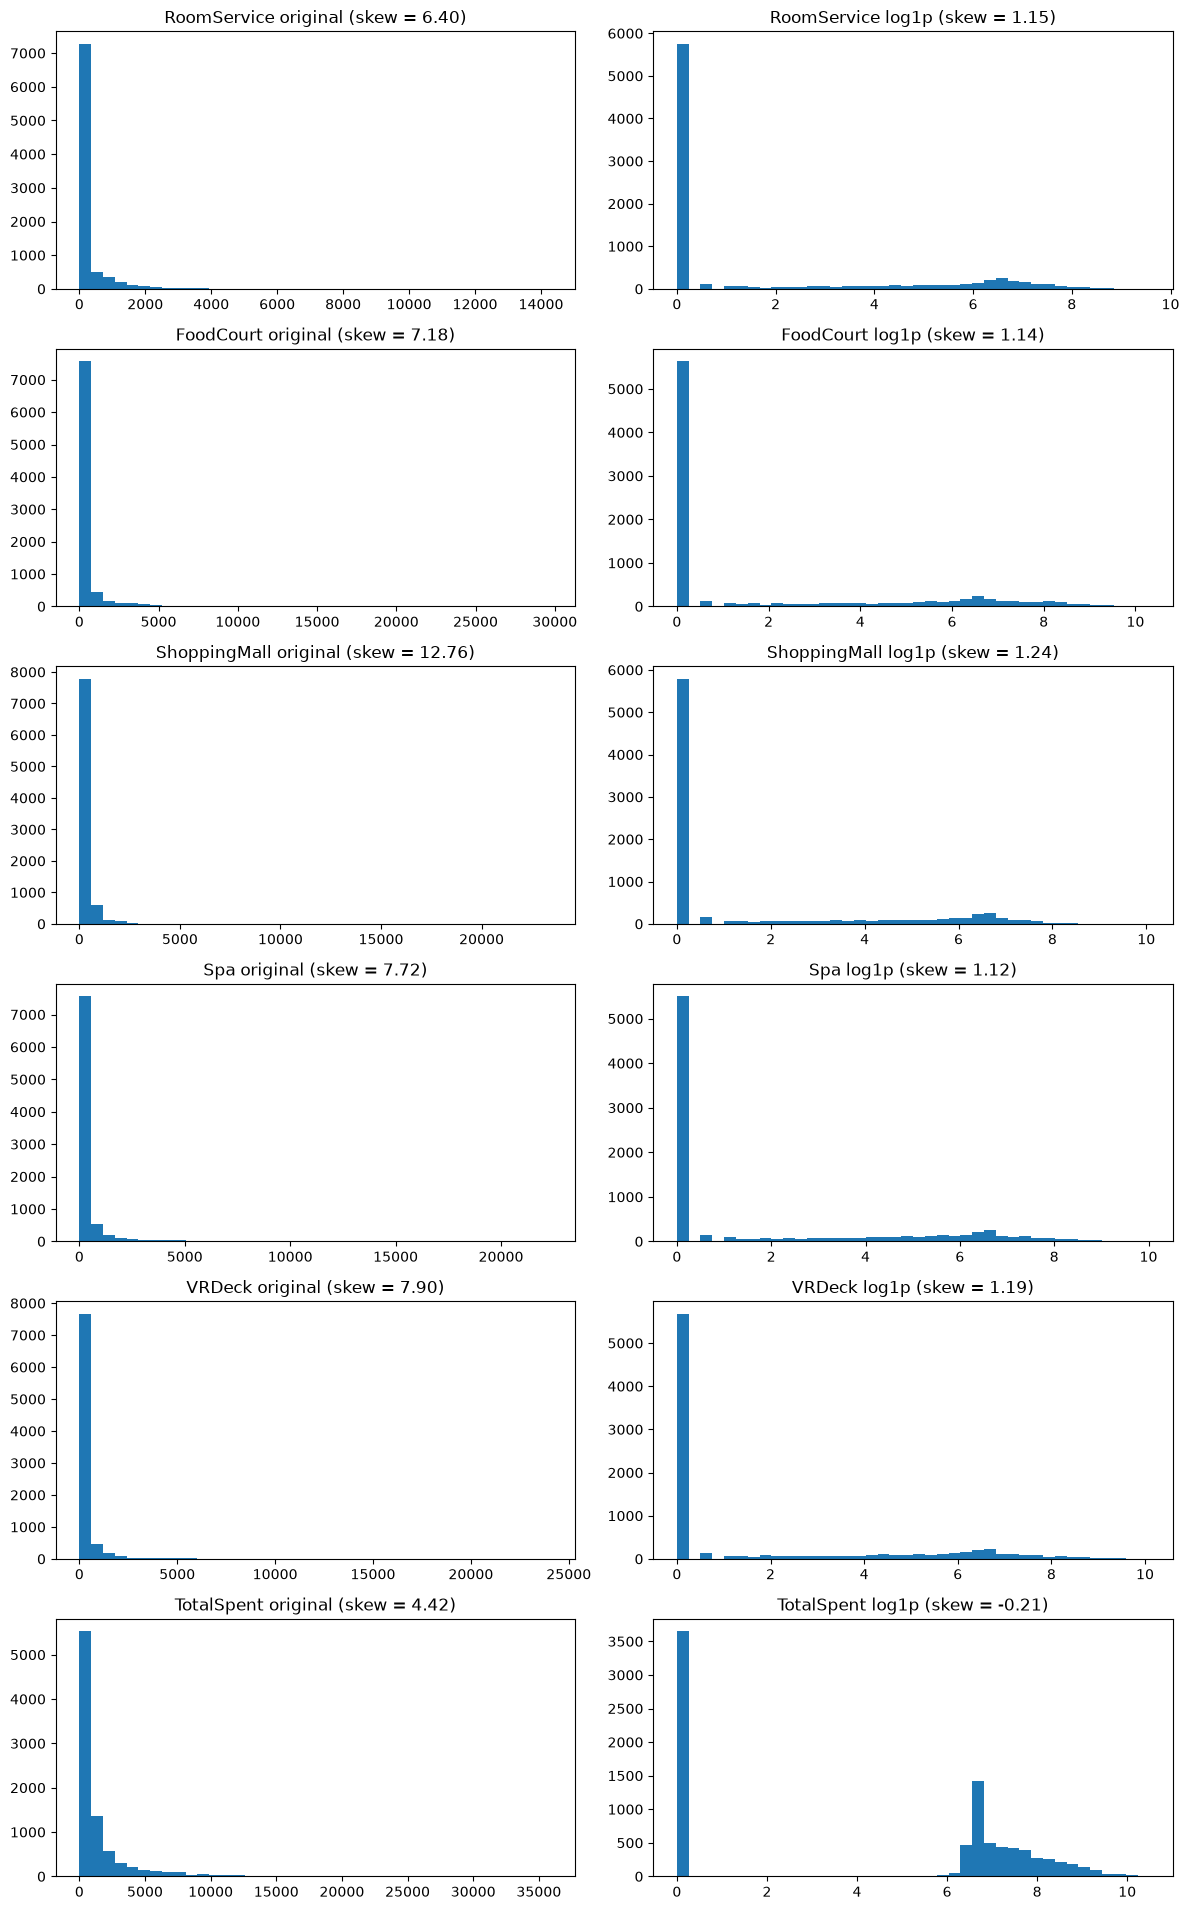

                      skew  outliers_iqr
RoomService_log   1.149866             1
FoodCourt_log     1.143177             0
ShoppingMall_log  1.238498            72
Spa_log           1.122324             1
VRDeck_log        1.193417            23
TotalSpent_log   -0.212435             0
Age               0.431102           162
Cabin_Num         0.677708             0


In [10]:
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
log_cols = spend_cols + ["TotalSpent"]
continuas = log_cols + ["Age", "Cabin_Num"]

print("Skewness antes de transformar:")
print(df_train[continuas].skew().sort_values(ascending=False))


fig, axes = plt.subplots(len(log_cols), 2, figsize=(12, 3.2 * len(log_cols)))

for i, col in enumerate(log_cols):
    original = df_train[col]
    transformada = np.log1p(original)

    axes[i, 0].hist(original, bins=40)
    axes[i, 0].set_title(f"{col} original (skew = {original.skew():.2f})")

    axes[i, 1].hist(transformada, bins=40)
    axes[i, 1].set_title(f"{col} log1p (skew = {transformada.skew():.2f})")

plt.tight_layout()
plt.show()


df_train[[f"{col}_log" for col in log_cols]] = np.log1p(df_train[log_cols])
df_train.drop(columns=log_cols, inplace=True)

continuas = [f"{col}_log" for col in log_cols] + ["Age", "Cabin_Num"]

def contar_outliers(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return int(((serie < q1 - 1.5 * iqr) | (serie > q3 + 1.5 * iqr)).sum())

resumen = pd.DataFrame({
    "skew": df_train[continuas].skew(),
    "outliers_iqr": [contar_outliers(df_train[c]) for c in continuas]
})
print(resumen)

Primero se ve el sesgo únicamente de las variables continuas, porque en las binarias y en las columnas dummy generadas en el paso anterior el skew no describe la forma de una distribución sino el desbalance.

Las cinco variables de gasto junto con TotalSpent presentan un sesgo positivo de entre 6.3 y 12.6, estos vienen por la gran cantidad de 0s en totalspent por la gente en **Cryo**.
Se usa una transformación logarítmica con log1p en lugar del logaritmo natural.
log1p mapea el 0, conserva el orden de los gastos y comprime la cola sin eliminar los valores extremos.

Al comparar los histogramas antes y después se observa que el sesgo baja de valores de 6-12 hasta magnitudes cercanas a 1, y que la cantidad de outliers detectados por Tukey disminuye de forma importante.

Age no se transformó tiene un sesgo de 0.419 este se encuentra dentro del rango de |0.5| que se considera simétrico, como se veia en el histograma. Cabin_Num tampoco se transformó,  su sesgo es moderado y se trata de su posición dentro del deck y no de una magnitud, por lo que comprimir logarítmicamente los números altos no funcionaría.

## 7. Escalado

* Aplica el escalador que corresponda según la presencia de outliers.
* Justifica la elección.


In [11]:
from sklearn.preprocessing import RobustScaler

y = df_train["Transported"]
X = df_train.drop(columns="Transported")

binarias = [c for c in X.columns if c not in continuas]
print("Binarias:", binarias)
print("Valores distintos en binarias:", sorted(pd.unique(X[binarias].values.ravel())))

antes = X[continuas].describe().T[["mean", "50%", "std", "min", "max"]]

scaler = RobustScaler()
X[continuas] = scaler.fit_transform(X[continuas])

despues = X[continuas].describe().T[["mean", "50%", "std", "min", "max"]]

print(pd.DataFrame({"centro": scaler.center_, "escala": scaler.scale_}, index=continuas))
print("\nAntes:\n", antes)
print("\nDespués:\n", despues)

Binarias: ['CryoSleep', 'Cabin_Side', 'GroupSize', 'IsAlone', 'HasSpent', 'IsChild', 'HomePlanet_Europa', 'HomePlanet_Mars', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Cabin_Deck_B', 'Cabin_Deck_C', 'Cabin_Deck_D', 'Cabin_Deck_E', 'Cabin_Deck_F', 'Cabin_Deck_G']
Valores distintos en binarias: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
                      centro      escala
RoomService_log     0.000000    3.737670
FoodCourt_log       0.000000    4.127134
ShoppingMall_log    0.000000    3.135494
Spa_log             0.000000    3.988984
VRDeck_log          0.000000    3.713572
TotalSpent_log      6.575076    7.273786
Age                27.000000   17.000000
Cabin_Num         448.000000  810.000000

Antes:
                         mean         50%         std  min          max
RoomService_log     1.735295    0.000000    2.719285  0.0     9.569971
FoodCourt_log       1.906543    0.000000    2.932951  

Se escalaron únicamente las variables continuas, las variables de gasto transformadas, Age y Cabin_Num. Las variables binarias y dummy no se escalaron porque ya se encuentran entre 0 y 1. Transported tampoco porque es la variable objetivo.

Se utilizó RobustScaler porque todavía existen outliers después de la transformación, principalmente en Age. Este scaler utiliza la mediana y el rango de cuartiles, por lo que los valores en los. extremos afectan menos el resultado.

También se descartó MinMaxScaler porque utiliza los valores mínimos y máximos, por lo que los outliers podrían comprimir demasiado el resto de los datos.

El scaler se ajustó únicamente con train y después se aplicará a test con transform para evitar usar información del conjunto de prueba durante el entrenamiento.

## 8. Verificación final

* Confirma que no quedan nulos en el conjunto procesado.
* Confirma que no quedan columnas de tipo object.
* Reporta el shape final del dataset procesado.
* Genera una tabla resumen de todas las decisiones tomadas: variable, tipo, tratamiento aplicado, justificación.
* Genera una breve conclusión con el análisis y hallazgos del conjunto de datos seleccionado.

In [12]:
# 1. Confirmar que no quedan nulos
nulos_X = X.isna().sum()
nulos_y = y.isna().sum()
print("Nulos en X:", nulos_X[nulos_X > 0] if nulos_X.sum() > 0 else "No quedan valores nulos en X.")
print("Nulos en y:", nulos_y if nulos_y > 0 else "No quedan valores nulos en y.")

# 2. Confirmar que no quedan columnas tipo object
cols_object = X.select_dtypes(include="object").columns.tolist()
print("\nColumnas tipo object:", cols_object if cols_object else "Ninguna, todas las columnas son numéricas.")

# 3. Shape final
print("\nShape final de X:", X.shape)
print("Shape final de y:", y.shape)

Nulos en X: No quedan valores nulos en X.
Nulos en y: No quedan valores nulos en y.

Columnas tipo object: Ninguna, todas las columnas son numéricas.

Shape final de X: (8693, 24)
Shape final de y: (8693,)


## Tabla de resumen

| Variable | Tipo | Tratamiento aplicado | Justificación |
|---|---|---|---|
| PassengerId | Identificador | Eliminada | Identificador único por fila, sin valor predictivo |
| Name | Texto | Eliminada | Identificador único (con repetidos/NaN), sin valor predictivo |
| Cabin | Categórica (compuesta) | Eliminada (descompuesta en Deck/Num/Side) | Cardinalidad altísima (6560 valores); redundante tras extraer sus componentes |
| VIP | Binaria | Eliminada | Desbalance extremo (97.7% False); diferencia con el target poco concluyente por bajo n |
| HomePlanet | Nominal | Imputación por moda + One-hot encoding (drop_first) | Sin orden natural entre categorías; baja cardinalidad; diferencia notable con el target (Earth 42.4%, Europa 65.9%, Mars 52.3%) |
| Destination | Nominal | Imputación por moda + One-hot encoding (drop_first) | Sin orden natural; baja cardinalidad; diferencia moderada con el target |
| Cabin_Deck | Nominal | Deck T fusionado con D + imputación por moda + One-hot encoding (drop_first) | Deck T con solo 5 registros (riesgo de aprender relación espuria); sin orden natural |
| Cabin_Side | Binaria | Imputación por moda + mapeo 0/1 (P=0, S=1) | Solo 2 categorías; diferencia moderada con el target (P 45.1% vs S 55.5%) |
| Cabin_Num | Numérica | Conversión a numérica + imputación por mediana (sin transformación ni escalado log) | Representa posición física en la nave, no una magnitud; sesgo moderado no justifica log; cardinalidad alta pero mediana no se ve afectada por ella |
| CryoSleep | Binaria | Imputación condicional (False si hay gasto > 0, moda en el resto) + mapeo a 0/1 | Faltante parcialmente informativo (en CryoSleep no se puede gastar); mayor poder discriminante del dataset (81.8% vs 32.9% transportados) |
| RoomService, FoodCourt, ShoppingMall, Spa, VRDeck | Numérica | Imputación condicional (0 si CryoSleep=True, mediana en el resto) + transformación log1p + RobustScaler | Faltante parcialmente informativo; sesgo positivo extremo (6.3–12.6) con muchos outliers (Tukey) |
| TotalSpent | Numérica (derivada) | Suma de gastos, recalculada tras imputación + log1p + RobustScaler | Captura el gasto total como señal agregada; mismo sesgo extremo que las variables de gasto individuales |
| HasSpent | Binaria (derivada) | Recalculada tras imputación (1 si TotalSpent > 0) | Señal simple de si el pasajero consumió algún servicio, complementa TotalSpent |
| IsChild | Binaria (derivada) | Recalculada tras imputación (1 si Age < 15) | Captura un posible efecto no lineal de la edad que Age por sí sola no refleja |
| Age | Numérica | Imputación por mediana (sin transformación log) | Faltante real sin relación recuperable; distribución casi normal (skew 0.419, dentro de rango simétrico) |
| Transported | Binaria (target) | Mapeo a 0/1 | Variable objetivo del problema de clasificación binaria |



## Conclusión
El dataset quedó completamente numérico, sin valores nulos y listo para modelar, con X conteniendo las variables predictoras escaladas y transformadas, y y la variable objetivo Transported. El hallazgo más relevante del análisis fue que CryoSleep es, por mucho, la variable con mayor poder discriminante (49 puntos de diferencia en tasa de transportados entre True y False), seguida por HomePlanet y las variables de gasto, cuya relación con el target solo se hizo evidente al segmentar por CryoSleep. El patrón de grupo detectado en PassengerId también resultó útil más allá de HomePlanet: permitió derivar GroupSize e IsAlone como variables predictoras adicionales. En contraste, Age no mostró relación aparente con la variable objetivo de forma agregada. El manejo cuidadoso de los faltantes informativos (especialmente en CryoSleep, los gastos y HomePlanet por consenso de grupo) permitió recuperar señal que se habría perdido con una imputación genérica, y las transformaciones aplicadas (log1p + RobustScaler) atienden directamente el sesgo extremo y los outliers detectados en el EDA.

---
## Preparación para modelado

In [13]:
# Reutilizamos en memoria el dataset ya procesado en la Parte 1 (Primer Avance),
# sin necesidad de exportarlo a CSV y volver a cargarlo.
df = df_train
print(f"Shape del dataset procesado: {df.shape}")
df.head()

Shape del dataset procesado: (8693, 25)


,CryoSleep,Age,Transported,Cabin_Num,Cabin_Side,GroupSize,IsAlone,HasSpent,IsChild,HomePlanet_Europa,...,Cabin_Deck_D,Cabin_Deck_E,Cabin_Deck_F,Cabin_Deck_G,RoomService_log,FoodCourt_log,ShoppingMall_log,Spa_log,VRDeck_log,TotalSpent_log
0,0,39.0,0,0.0,0,1,1,0,0,1,...,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0,24.0,1,0.0,1,1,1,1,0,0,...,0,0,1,0,4.700480,2.302585,3.258097,6.309918,3.806662,6.602588
2,0,58.0,0,0.0,1,2,0,1,0,1,...,0,0,0,0,3.784190,8.182280,0.000000,8.812248,3.912023,9.248021
3,0,33.0,0,0.0,1,2,0,1,0,1,...,0,0,0,0,0.000000,7.157735,5.918894,8.110728,5.267858,8.551981
4,0,16.0,1,1.0,1,1,1,1,0,0,...,0,0,1,0,5.717028,4.262680,5.023881,6.338594,1.098612,6.995766


In [14]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="Transported")
y = df["Transported"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (6954, 24) Test: (1739, 24)


In [15]:
from sklearn.metrics import (
    recall_score,
    f1_score,
    accuracy_score,
    precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt


In [16]:
def evaluar_spaceship_model(y_test, y_pred, modelo_nombre="Modelo"):
    print(f"--- Evaluación de: {modelo_nombre} ---")

    # 1. Calcular la Matriz de Confusión para extraer TN, FP, FN, TP
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # 2. Calcular las métricas directas
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    # 3. Calcular Specificity (Tasa de Verdaderos Negativos)
    specificity = tn / (tn + fp)

    # 4. Reporte alineado a tus prioridades
    print(f"Métrica Principal (Criterio de decisión):")
    print(f" * Recall:      {recall:.4f}")

    print(f"\nMétrica Secundaria (Filtro de calidad):")
    print(f" * F1-Score:    {f1:.4f}")

    print(f"\nMétricas de Referencia / Contexto:")
    print(f" * Accuracy:    {accuracy:.4f}")
    print(f" * Precision:   {precision:.4f}")
    print(f" * Specificity: {specificity:.4f}")

    # 5. Visualizar el trade-off con la Matriz de Confusión
    print("\nGenerando Matriz de Confusión...")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No transportado (0)", "Transportado (1)"])
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"Matriz de Confusión - {modelo_nombre}")
    plt.show()


In [17]:
from sklearn.dummy import DummyClassifier

def calcular_metricas(y_test, y_pred, modelo_nombre):
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    return {
        "Modelo": modelo_nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "Specificity": tn / (tn + fp),
        "FN": fn,
        "FP": fp
    }

# Baseline: predice siempre la clase mayoritaria (Transported = 1),
# el minimo desempeño que cualquier modelo entrenado debe superar.
baseline_model = DummyClassifier(strategy="most_frequent", random_state=42)
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)


## 1. Diagnóstico del modelo base

- Genera la curva de aprendizaje del mejor modelo de tu entrega anterior.
- Genera la curva de validación para al menos dos hiperparámetros relevantes de dicho modelo.
- Interpreta ambas curvas: ¿hay overfitting?, ¿underfitting?, ¿necesitas más datos?, ¿qué rango de hiperparámetros tiene sentido explorar?

In [18]:
#librerias
from sklearn.model_selection import learning_curve
from sklearn.model_selection import validation_curve
from xgboost import XGBClassifier


In [19]:
#modelo
xgb_lc = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.065,
    min_child_weight=1,
    subsample=0.8,
    random_state=42,
    eval_metric='logloss'
)

### Curvas de aprendizaje

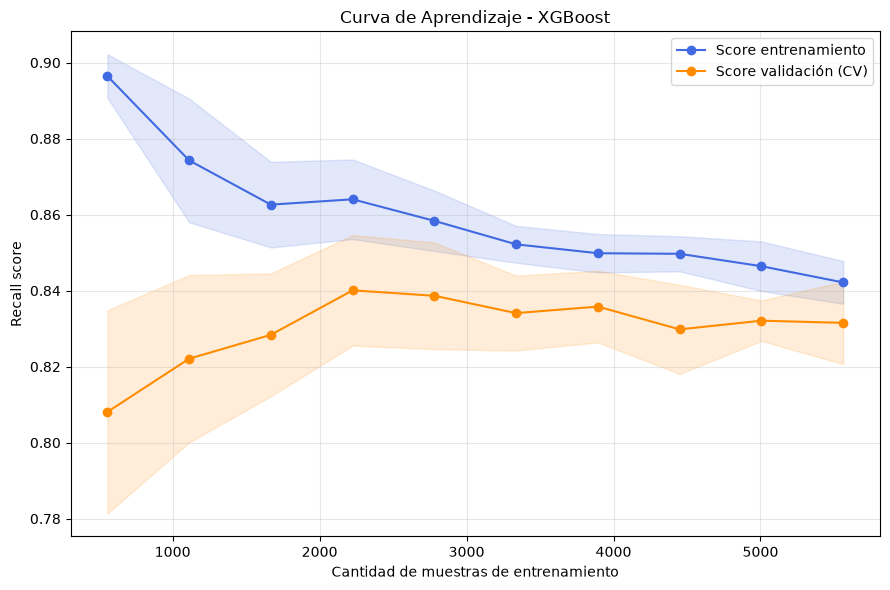

In [20]:
#Curva de aprendizaje del recall (metrica principal)
# Tamaños de entrenamiento a evaluar (10%, 20%, ..., 100% de los datos)
train_sizes = np.linspace(0.1, 1.0, 10)

train_sizes_abs, train_scores, val_scores = learning_curve(
    estimator=xgb_lc,
    X=X_train,
    y=y_train,
    train_sizes=train_sizes,
    cv=5,                      # validación cruzada de 5 folds
    scoring='recall',
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

# Promedios y desviaciones estándar
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

# Gráfico
plt.figure(figsize=(9, 6))
plt.plot(train_sizes_abs, train_mean, 'o-', color='royalblue', label='Score entrenamiento')
plt.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std,
                  alpha=0.15, color='royalblue')

plt.plot(train_sizes_abs, val_mean, 'o-', color='darkorange', label='Score validación (CV)')
plt.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std,
                  alpha=0.15, color='darkorange')

plt.title('Curva de Aprendizaje - XGBoost')
plt.xlabel('Cantidad de muestras de entrenamiento')
plt.ylabel('Recall score')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

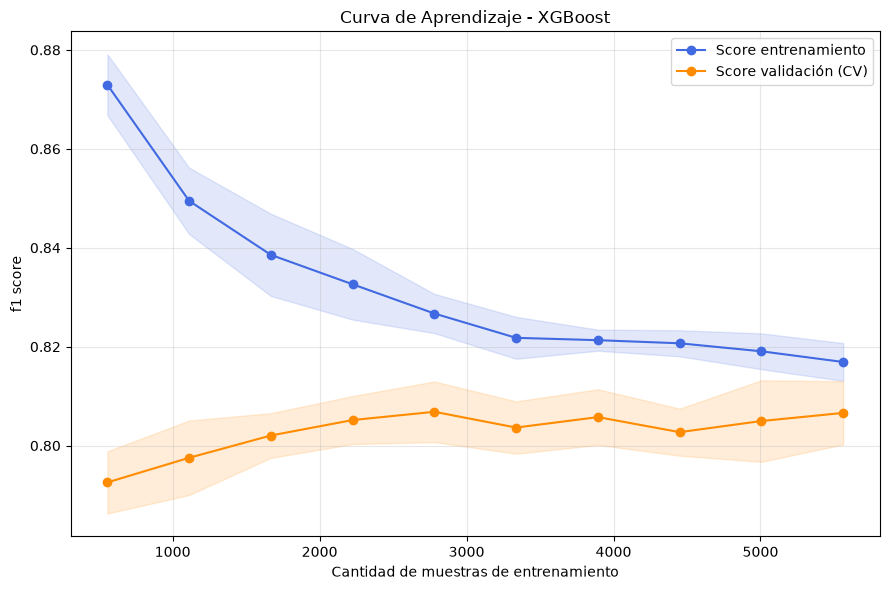

In [21]:
#Curva de aprendizaje del f1 score (metrica secundaria)
#Tamaños de entrenamiento a evaluar (10%, 20%, ..., 100% de los datos)
train_sizes = np.linspace(0.1, 1.0, 10)

train_sizes_abs, train_scores, val_scores = learning_curve(
    estimator=xgb_lc,
    X=X_train,
    y=y_train,
    train_sizes=train_sizes,
    cv=5,                      # validación cruzada de 5 folds
    scoring='f1',
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

# Promedios y desviaciones estándar
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

# Gráfico
plt.figure(figsize=(9, 6))
plt.plot(train_sizes_abs, train_mean, 'o-', color='royalblue', label='Score entrenamiento')
plt.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std,
                  alpha=0.15, color='royalblue')

plt.plot(train_sizes_abs, val_mean, 'o-', color='darkorange', label='Score validación (CV)')
plt.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std,
                  alpha=0.15, color='darkorange')

plt.title('Curva de Aprendizaje - XGBoost')
plt.xlabel('Cantidad de muestras de entrenamiento')
plt.ylabel('f1 score')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Curvas de validación
Aunque las instrucciones indican que se realicen las curvas de los dos parámetros más importantes, se creyó pertinente analizar los primeros tres, los cuales son *('n_estimators')* *('max_depth')* *('learning_rate')* esto debido a que aunque los primeros dos parametros son indiscutiblemente los más decisivos en el modelo, en el ejercicio anterior encontramos nuestro una mejora al modelo base modificando el *learning rate*.



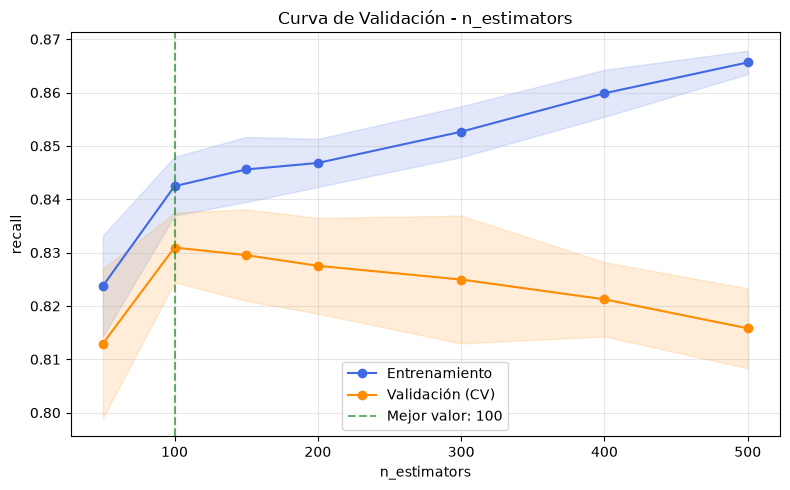

n_estimators: mejor valor = 100 (score=0.8310)


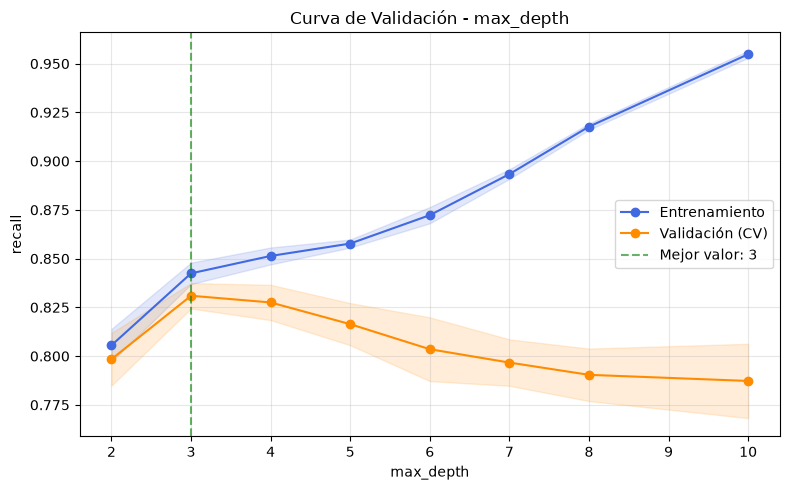

max_depth: mejor valor = 3 (score=0.8310)


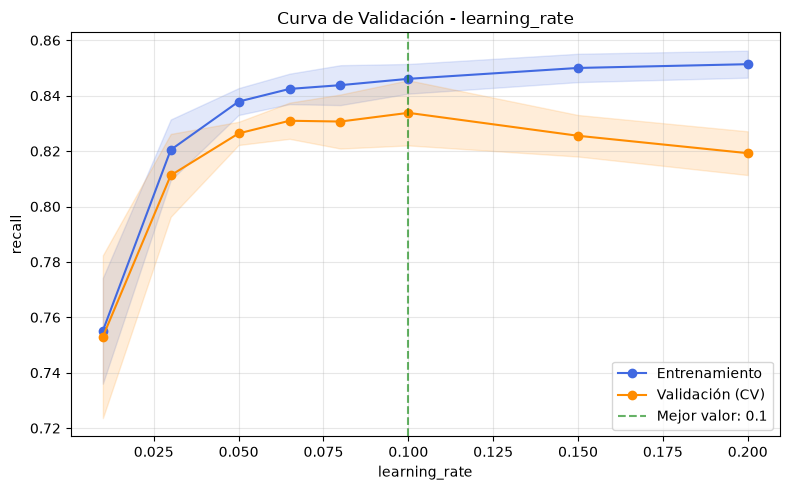

learning_rate: mejor valor = 0.1 (score=0.8338)

Resumen de mejores valores individuales:
  n_estimators: 100
  max_depth: 3
  learning_rate: 0.1


In [22]:
#curvas de validación

# Parámetros base (fijos) — se usan como referencia para todos los gráficos
base_params = dict(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.065,
    min_child_weight=1,
    subsample=0.8,
    random_state=42,
    eval_metric='logloss'
)

# Diccionario: parámetro -> rango de valores a probar
param_grid = {
    'n_estimators':     [50, 100, 150, 200, 300, 400, 500],
    'max_depth':        [2, 3, 4, 5, 6, 7, 8, 10],
    'learning_rate':    [0.01, 0.03, 0.05, 0.065, 0.08, 0.1, 0.15, 0.2],
}

def plot_validation_curve(param_name, param_range, cv=5, scoring='recall'):
    # Modelo base sin el parámetro que vamos a variar
    params = {k: v for k, v in base_params.items() if k != param_name}

    train_scores, val_scores = validation_curve(
        estimator=XGBClassifier(**params),
        X=X_train,
        y=y_train,
        param_name=param_name,
        param_range=param_range,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(param_range, train_mean, 'o-', color='royalblue', label='Entrenamiento')
    plt.fill_between(param_range, train_mean - train_std, train_mean + train_std,
                      alpha=0.15, color='royalblue')

    plt.plot(param_range, val_mean, 'o-', color='darkorange', label='Validación (CV)')
    plt.fill_between(param_range, val_mean - val_std, val_mean + val_std,
                      alpha=0.15, color='darkorange')

    # Marca el mejor valor según validación
    best_idx = np.argmax(val_mean)
    plt.axvline(param_range[best_idx], color='green', linestyle='--', alpha=0.6,
                label=f'Mejor valor: {param_range[best_idx]}')

    plt.title(f'Curva de Validación - {param_name}')
    plt.xlabel(param_name)
    plt.ylabel(scoring)
    plt.legend(loc='best')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return param_range[best_idx], val_mean[best_idx]

# Generar la curva para cada parámetro
best_values = {}
for param_name, param_range in param_grid.items():
    best_val, best_score = plot_validation_curve(param_name, param_range)
    best_values[param_name] = best_val
    print(f"{param_name}: mejor valor = {best_val} (score={best_score:.4f})")

print("\nResumen de mejores valores individuales:")
for k, v in best_values.items():
    print(f"  {k}: {v}")

### Interpretación de las curvas
####Curvas de aprendizaje
El modelo presenta un fit prácticamente adecuado, con muy leve tendencia a underfitting: las curvas de aprendizaje muestran que tanto el score de entrenamiento como el de validación convergen hacia una brecha pequeña (0.01-0.02), descartando overfitting severo, pero la curva de validación se aplana a partir de las 2000-2500 muestras oscilando sin tendencia clara de seguir subiendo pese a duplicarse el tamaño del set de entrenamiento, e incluso el score de entrenamiento también desciende y se estabiliza en un nivel relativamente bajo (0.82-0.84) en vez de mantenerse alto; esto sugiere que el modelo no está sufriendo de alta varianza y no está limitado por falta de datos, sino que alcanzó un techo de desempeño consistente con un problema de sesgo o de información disponible en las features, por lo que agregar más muestras del mismo tipo de datos tendría rendimientos marginales decrecientes y no rompería ese techo. La vía de mejora está en la calidad y capacidad representativa de los datos/modelo, no en su cantidad.


####Curvas de validación
De acuerdo a las curvas de validación se puede nver los siguientes rangos recomendados:

n_estimators: El score de validación alcanza su pico en 100 y decae de forma sostenida a partir de ahí (100→500), mientras el train sigue subiendo — señal clara de overfitting creciente con más árboles. Rango sensato: 75–150 (evitar irse mucho más allá de 100-150).

max_depth: El patrón es el más claro de overfitting: validación pico en 3, y cae de forma consistente y pronunciada de 3 a 10, mientras train se dispara hasta 0.95. Rango sensato: 2–4 (no tiene sentido explorar más allá de 5, el daño ya es evidente).

learning_rate: Validación sube fuerte de 0.01 a 0.05-0.10 (train y val convergen bien ahí), luego empieza a decaer levemente después de 0.10. Rango sensato: 0.03–0.10.

Dado que las curvas de validación ya delimitaron rangos estrechos y bien definidos para cada hiperparámetro clave, la decisión final es usar Grid Search (con cv=5) sobre el siguiente espacio de búsqueda: max_depth en [2, 3, 4], learning_rate en [0.03, 0.05, 0.065, 0.08, 0.10], y n_estimators en [75, 100, 125, 150], dado que un grid exhaustivo es computacionalmente viable en este rango acotado (60 combinaciones) y permite capturar por completo la interacción conocida entre learning_rate y n_estimators, algo que un muestreo aleatorio podría no cubrir de forma completa.

## 2. Tuning de hiperparámetros

- Elige entre GridSearchCV o RandomizedSearchCV y justifica tu elección en función del espacio de búsqueda.
- Define la grilla o distribución de hiperparámetros. Justifica cada rango elegido con base en las curvas de validación del paso anterior.
- No olvides usar K-Fold dentro de la búsqueda de hiperparámetros, elige una K óptima y justifica la elección.
- Reporta los mejores hiperparámetros encontrados y el score en CV.
- Elige mínimo 2 métricas de evaluación justificadas con base en las características del dataset.

In [23]:
#Balance
conteo = y_train.value_counts()
proporcion = y_train.value_counts(normalize=True)
print("Conteo:\n", conteo)
print("\nProporción:\n", proporcion)

Conteo:
 Transported
1    3502
0    3452
Name: count, dtype: int64

Proporción:
 Transported
1    0.503595
0    0.496405
Name: proportion, dtype: float64


In [24]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, f1_score, classification_report

param_grid = {
    'n_estimators': [75, 100, 125, 150],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.03, 0.05, 0.065, 0.08,  0.1],
    'scale_pos_weight': [1, 1.2, 1.5, 2]
}

xgb_base = XGBClassifier(
    min_child_weight=1,
    subsample=0.8,
    random_state=42,
    eval_metric='logloss'
)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='recall',
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)
print(f"\nMejor recall promedio en CV: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 240 candidates, totalling 1200 fits
Mejores hiperparámetros encontrados:
{'learning_rate': 0.08, 'max_depth': 2, 'n_estimators': 100, 'scale_pos_weight': 2}

Mejor recall promedio en CV: 0.9038


In [25]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import precision_score

best_model = grid_search.best_estimator_

f1_scores = cross_val_score(best_model, X_train, y_train, cv=cv_strategy, scoring='f1', n_jobs=-1)
print(f"F1 promedio en CV con el mejor modelo: {f1_scores.mean():.4f} (+/- {f1_scores.std():.4f})")
precision_scores = cross_val_score(best_model, X_train, y_train, cv=cv_strategy, scoring='precision', n_jobs=-1)
print(f"Precision promedio en CV: {precision_scores.mean():.4f} (+/- {precision_scores.std():.4f})")

F1 promedio en CV con el mejor modelo: 0.8073 (+/- 0.0085)
Precision promedio en CV: 0.7295 (+/- 0.0094)


**Elección del método de búsqueda**

Se eligió GridSearchCV sobre RandomizedSearchCV porque el espacio de búsqueda ya estaba acotado por las curvas de validación argumentado en el punto anterior. Con 4 valores de n_estimators, 3 de max_depth, 5 de learning_rate y 4 de scale_pos_weight (240 combinaciones) se considera computacionalmente viable.

**Definición y justificación de la grilla**
* `n_estimators: [75, 100, 125, 150]`. La curva de validación del punto 1 mostró el pico de recall en 100, con decaimiento sostenido a partir de ahí conforme el train score seguía subiendo (overfitting creciente). Se buscó con resolución fina alrededor de ese pico.
* `max_depth: [2, 3, 4]`. La curva de validación mostró el patrón de overfitting más marcado de los tres parámetros: pico en 3, caída pronunciada y consistente hacia valores mayores. No tiene sentido explorar más allá de 4.
* `learning_rate: [0.03, 0.05, 0.065, 0.08, 0.1]`. La curva mostró una subida fuerte entre 0.01 y 0.05-0.10, con decaimiento leve después de 0.10. Se cubrió ese rango completo con mayor resolución que en el análisis exploratorio inicial.
* `scale_pos_weight: [1, 1.2, 1.5, 2]`. Este parámetro no proviene del análisis de curvas de validación del punto 1, ya que no fue explorado ahí. Su inclusión responde a un criterio distinto ya que se verificó que las clases están prácticamente balanceadas (50.4% vs 49.6%, ratio negativos/positivos de 0.986), por lo que no existe un problema de desbalance estadístico que corregir. Sin embargo, el costo de los errores no es simétrico para este problema: un falso negativo (no detectar a un pasajero transportado) es el error crítico a minimizar. scale_pos_weight permite introducir concientemente un sesgo hacia el recall en la función de pérdida del modelo, como una decisión de diseño orientada al costo del error, no como una corrección de desbalance de clases.

**Estrategia de validación cruzada**
Se utilizó StratifiedKFold con K=5 con aproximadamente 6954 muestras de entrenamiento, K=5 genera folds de validación de un tamaño suficiente (1390 muestras aprox) para obtener estimaciones estables del recall, sin sacrificar una porción excesiva de datos de entrenamiento en cada partición.

**Mejores hiperparámetros y score en CV**
La búsqueda encontró como óptimo: n_estimators=100, max_depth=2, learning_rate=0.08, scale_pos_weight=2, con un recall promedio en validación cruzada de 0.9038.
Podemos ver que max_depth=2 difiere del pico de 3 encontrado en la curva de validación univariada del punto 1. Esto no necesariamente contradice ese análisis, sino que revela una interacción entre max_depth y scale_pos_weight, la curva de validación del punto 1 se generó con scale_pos_weight=1 fijo, mientras que la búsqueda conjunta permite que ambos parámetros se muevan simultáneamente. Al aumentar el peso de la clase positiva, el punto óptimo de profundidad del árbol se desplaza.

**Métricas de evaluación elegidas y justificación**
Se usaron tres métricas, no solo las dos mínimas requeridas, dado el trade-off que se buscaba explorar deliberadamente:
* **Recall (primaria)**: principal métrica de evaluación del problema, donde un falso negativo (pasajero transportado no detectado) representa el error de mayor costo.
* **Precision (complementaria)**: necesaria para cuantificar el costo de optimizar agresivamente el recall, dado que ambas métricas están en relacionadas directamente.
* **F1-score (de balance)**: permite verificar que la ganancia en recall no se logró a costa de una caída muy grande en la precision.

**Interpretación de los resultados**

| Métrica | Score en CV |
|---|---|
| Recall | 0.9038 |
| Precision | 0.7295 |
| F1-score | 0.8073 |

El tuning con scale_pos_weight logró romper el techo de recall identificado en el diagnóstico del punto 1 (83-85%), llevándolo hasta 90.38%. Este resultado confirma la hipótesis planteada en ese diagnóstico: el modelo base no estaba limitado por una falta de datos ni por una mala calibración de su complejidad (n_estimators, max_depth, learning_rate ya estaban cerca de su óptimo individual), sino por un punto de decisión (el peso implícito 1:1 entre clases en la función de pérdida) que no favorecía la métrica prioritaria del problema.

La mejora tuvo un costo esperado: la precision cayó a 72.95%, reflejando que el modelo ahora clasifica más casos como positivos, incluyendo más falsos positivos, a cambio de capturar más verdaderos positivos. El F1-score de 0.8073 confirma que el balance general se mantiene razonable, sin colapsar, pero el resultado debe leerse explícitamente como una decisión de trade-off alineada con el objetivo del problema (minimizar falsos negativos), y no como una mejora general del modelo en sí.

## 3. Evaluación final

- Evalúa el modelo tuneado sobre el dataset de pruebas con las métricas elegidas.
- Genera la matriz de confusión e interpreta los errores en el contexto del problema.
- Compara baseline vs modelo anterior vs modelo tuneado en una tabla y una visualización.
- Justifica si el tuning mejoró el rendimiento y por qué crees que pasó lo que pasó.

--- Evaluación de: XGBoost Tuneado (GridSearchCV, scale_pos_weight) ---
Métrica Principal (Criterio de decisión):
 * Recall:      0.8995

Métrica Secundaria (Filtro de calidad):
 * F1-Score:    0.8070

Métricas de Referencia / Contexto:
 * Accuracy:    0.7832
 * Precision:   0.7317
 * Specificity: 0.6651

Generando Matriz de Confusión...


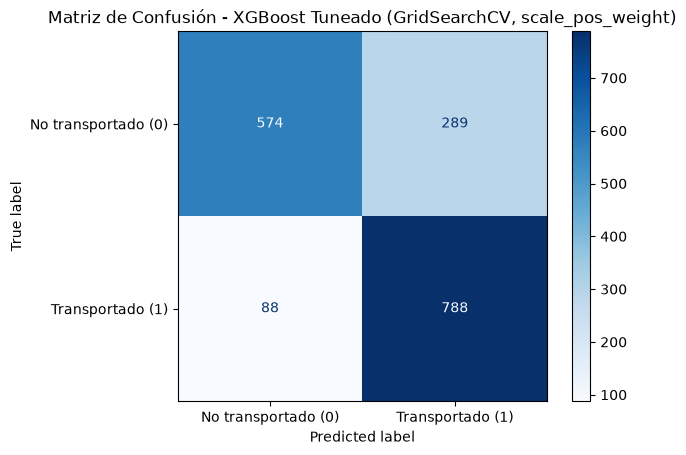

In [26]:
xgb_lc.fit(X_train, y_train)
y_pred_anterior = xgb_lc.predict(X_test)

# Modelo tuneado: el ganador del GridSearchCV de la sección 2
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

evaluar_spaceship_model(y_test, y_pred_tuned, "XGBoost Tuneado (GridSearchCV, scale_pos_weight)")

Interpretación de la matriz de confusión modelo tuneado

El Recall en test (89.95%) queda prácticamente idéntico al 90.38% obtenido en validación cruzada, y el F1 en test (0.8070) replica casi exactamente el F1 en CV (0.8073). Esto es una señal muy fuerte de que el tuning generaliza bien y no es un artefacto de sobreajuste a los folds de GridSearchCV: el modelo se comporta en datos nunca vistos igual que en la validación cruzada.

Del total de 876 pasajeros que sí fueron transportados en el conjunto de prueba, el modelo solo deja pasar 88 falsos negativos (10.05%), frente a los 143 que cometía el modelo anterior una reducción del 38.5% en el error más costoso del problema. Cada uno de esos 88 casos es un pasajero que el sistema reporta como "a salvo" cuando en realidad fue transportado a la dimensión alternativa, por lo que no se despliega ningún esfuerzo de búsqueda y rescate para él: es el error que, según el criterio de negocio definido desde la sección 2, se debe minimizar por encima de todo.

La contraparte es que los falsos positivos suben de 194 a 289 (33% de los 863 pasajeros realmente no transportados). Este es el error "barato" del problema: significa movilizar recursos de búsqueda hacia alguien que no lo necesitaba, un costo operativo pero sin consecuencias irreversibles. Ese desplazamiento se refleja directamente en la caída de Specificity (77.52% → 66.51%) y Precision (79.07% → 73.17%): el modelo ahora es más "alarmista", clasifica más casos como positivos en general, y ese es exactamente el trade-off que scale_pos_weight=2 fue diseñado para producir.



In [27]:
# 3.2 Comparativa: baseline vs modelo anterior vs modelo tuneado

resultados_finales = [
    calcular_metricas(y_test, y_pred_baseline, "Baseline (clase mayoritaria)"),
    calcular_metricas(y_test, y_pred_anterior,  "Modelo anterior (XGBoost, learning_rate=0.065)"),
    calcular_metricas(y_test, y_pred_tuned,     "Modelo tuneado (XGBoost + GridSearchCV)"),
]

tabla_final = pd.DataFrame(resultados_finales).set_index("Modelo").round(4)
tabla_final

,Accuracy,Precision,Recall,F1-score,Specificity,FN,FP
Modelo,,,,,,,
Baseline (clase mayoritaria),0.5037,0.5037,1.0000,0.6700,0.0000,0,863
"Modelo anterior (XGBoost, learning_rate=0.065)",0.8062,0.7907,0.8368,0.8131,0.7752,143,194
Modelo tuneado (XGBoost + GridSearchCV),0.7832,0.7317,0.8995,0.8070,0.6651,88,289


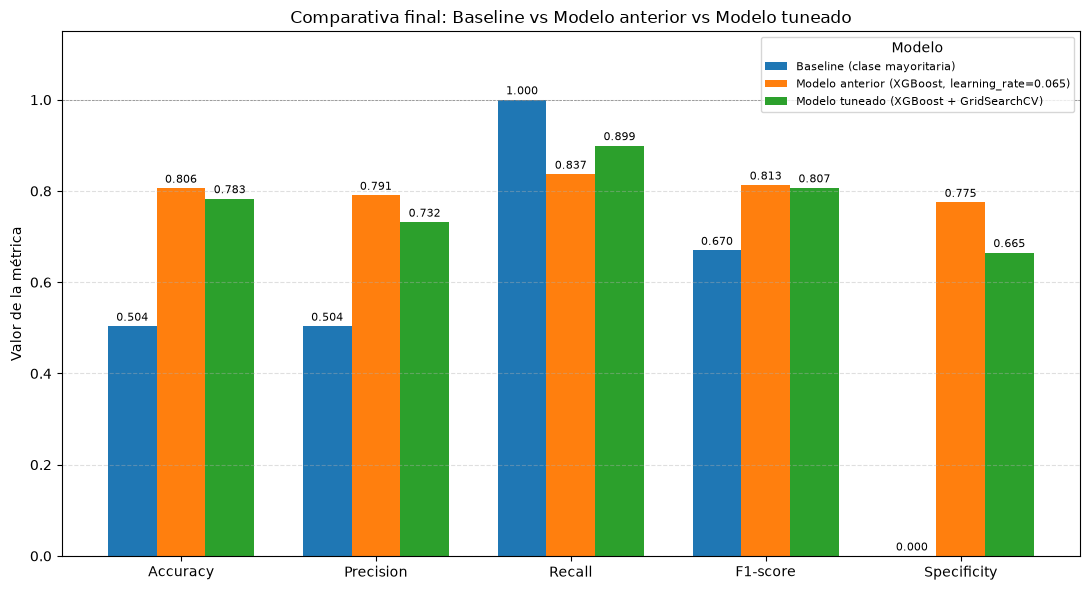

In [42]:
# Visualización comparativa
metricas_plot = ["Accuracy", "Precision", "Recall", "F1-score", "Specificity"]
modelos_plot = tabla_final.index.tolist()

x = np.arange(len(metricas_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 6))

for i, modelo in enumerate(modelos_plot):
    valores = tabla_final.loc[modelo, metricas_plot].values
    barras = ax.bar(x + (i - 1) * width, valores, width, label=modelo)
    ax.bar_label(barras, fmt="%.3f", padding=2, fontsize=8)

ax.set_ylabel("Valor de la métrica")
ax.set_title("Comparativa final: Baseline vs Modelo anterior vs Modelo tuneado")
ax.set_xticks(x)
ax.set_xticklabels(metricas_plot)
ax.set_ylim(0, 1.15)
ax.axhline(1.0, color="gray", linewidth=0.5, linestyle="--")
ax.legend(title="Modelo", fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

Justificación: ¿el tuning mejoró el rendimiento y por qué?

El baseline sigue sin ser una alternativa real: su Recall de 1.0 es trivial (predice siempre "Transportado") y su Specificity de 0.0 confirma que no identifica ni un solo pasajero no transportado.

Comparando modelo anterior vs modelo tuneado, la respuesta depende de qué métrica se mire, y esa es justo la conclusión correcta a defender:

* **Recall** (la métrica prioritaria del equipo): subió de 83.68% a 89.95%, es decir, 6.3 puntos porcentuales, equivalentes a 55 pasajeros transportados adicionales que ahora sí son detectados (143 FN → 88 FN). Bajo el criterio de decisión que se fijó, esto sí representa una mejora.
* **Precision y Specificity** bajaron (79.07%→73.17% y 77.52%→66.51%), porque el modelo ahora produce más falsos positivos (194→289). Este es el costo esperado y aceptado del trade-off, no un fallo del tuning.
* **F1-score** se mantuvo prácticamente igual (0.8131 → 0.8070, -0.6 puntos), lo que confirma que la ganancia en recall no vino de que el modelo colapsara prediciendo casi todo como positivo; el balance global precision-recall apenas se movió.
* **Accuracy** cayó de 80.62% a 78.32% (-2.3 puntos). Esta es la única métrica donde el modelo tuneado "empeora" de forma visible, y es exactamente por lo que el equipo decidió desde el principio no usar accuracy como criterio: con clases balanceadas, cambiar 55 FN por 95 FP adicionales mueve el acierto global hacia abajo, aunque el objetivo de negocio (minimizar FN) se haya cumplido mejor.

¿Por qué pasó lo que pasó? El diagnóstico de la sección 1 (curvas de aprendizaje/validación) ya mostraba que el modelo anterior había tocado un techo de sesgo, no de varianza ni de datos: max_depth, n_estimators y learning_rate ya estaban cerca de su óptimo individual con la función de pérdida estándar (peso implícito 1:1 entre clases). El GridSearchCV no mejoró el modelo ajustando capacidad, sino agregando scale_pos_weight, un parámetro que no busca "aprender mejor" el patrón sino desplazar deliberadamente el punto de operación del clasificador a lo largo de la frontera precision-recall, hacia el extremo que menos falsos negativos genera. El hecho de que el Recall y el F1 en test (0.8995 y 0.8070) prácticamente calquen los valores de CV (0.9038 y 0.8073) confirma que esta mejora es real y generaliza, no un artefacto de sobreajustar la búsqueda a los folds de validación cruzada. En resumen: el tuning sí mejoró el rendimiento en el sentido que le importa al negocio (menos pasajeros abandonados sin búsqueda), a costa de un trade-off consciente en accuracy, precision y specificity que es exactamente la decisión que se buscaba tomar desde que se definió el Recall como métrica principal.

## 4. Componente individual

Esta sección tiene una subsección por cada integrante, identificada con su nombre completo. Cada integrante trabaja de forma independiente:

- Elige un modelo de familia distinta al del equipo.
- Tunealo con GridSearch o RandomizedSearch con al menos 3 hiperparámetros.
- Evalúalo con las mismas métricas del equipo.
- Compara sus resultados contra el modelo final del equipo: ¿cambiarías la decisión del equipo?, ¿por qué sí o por qué no?

### Saúl Caballero Castor (Regresión Logística)

/opt/conda/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/conda/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/conda/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead o

{'C': 0.01, 'class_weight': None, 'penalty': 'l2'}
0.7964075810067252
--- Evaluación de: Logistic Regression ---
Métrica Principal (Criterio de decisión):
 * Recall:      0.8002

Métrica Secundaria (Filtro de calidad):
 * F1-Score:    0.7854

Métricas de Referencia / Contexto:
 * Accuracy:    0.7798
 * Precision:   0.7712
 * Specificity: 0.7590

Generando Matriz de Confusión...


/opt/conda/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


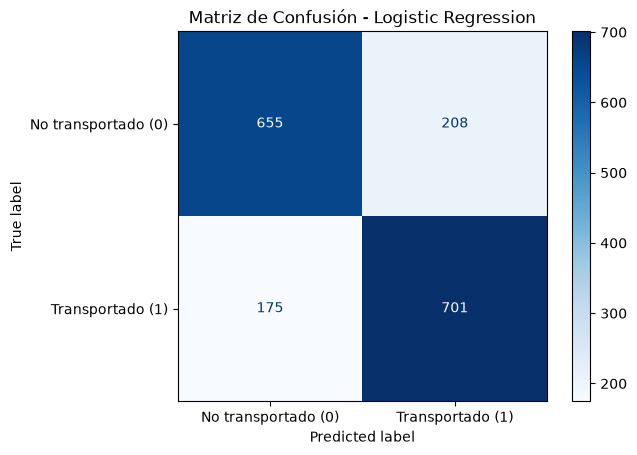

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'class_weight': [None, 'balanced']
}

model_base = LogisticRegression(solver='liblinear', max_iter=1000, random_state=42)

grid_lr = GridSearchCV(
    estimator=model_base,
    param_grid=params,
    scoring='recall',
    cv=cv_strategy,
    n_jobs=-1,
)

grid_lr.fit(X_train, y_train)

print(grid_lr.best_params_)
print(grid_lr.best_score_)

best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test)

evaluar_spaceship_model(y_test, y_pred_lr, "Logistic Regression")


In [44]:
resultados_lr = [
    calcular_metricas(y_test, y_pred_baseline, "Baseline (clase mayoritaria)"),
    calcular_metricas(y_test, y_pred_tuned, "XGBoost tuneado (equipo)"),
    calcular_metricas(y_test, y_pred_lr, "Regresión Logística (individual)"),
]

tabla_comparativa_lr = pd.DataFrame(resultados_lr).set_index("Modelo").round(4)
tabla_comparativa_lr


,Accuracy,Precision,Recall,F1-score,Specificity,FN,FP
Modelo,,,,,,,
Baseline (clase mayoritaria),0.5037,0.5037,1.0000,0.6700,0.0000,0,863
XGBoost tuneado (equipo),0.7832,0.7317,0.8995,0.8070,0.6651,88,289
Regresión Logística (individual),0.7798,0.7712,0.8002,0.7854,0.7590,175,208


**¿Cambiarías la decisión del equipo?**

No.

El GridSearchCV encontró como óptimo `C=0.01` (regularización L2 fuerte), `class_weight=None`, con un recall promedio en CV de 0.7964 — prácticamente idéntico al recall en test (0.8002), lo que confirma que el modelo generaliza bien y no hay overfitting en el tuning.

Sin embargo, en la métrica prioritaria del equipo el resultado es claro: la Regresión Logística obtiene 80.02% de recall frente al 89.95% del XGBoost tuneado, una diferencia de casi 10 puntos porcentuales. En términos absolutos, la Regresión Logística deja 175 falsos negativos frente a los 88 del equipo, es decir, 87 pasajeros transportados adicionales que este modelo no detecta y que, bajo el criterio de negocio definido desde la sección 2, representan el error más costoso del problema (pasajeros que no reciben ningún esfuerzo de búsqueda y rescate).

La Regresión Logística sí es mejor en Precision (77.12% vs 73.17%) y Specificity (75.90% vs 66.51%), cometiendo menos falsos positivos (208 vs 289). Pero ese es justamente el error "barato" del problema, así que esta ventaja no compensa la pérdida de recall.

Que el mejor `C` encontrado sea tan bajo (0.01, es decir, regularización fuerte que empuja a un modelo más simple) sugiere que la frontera de decisión que mejor separa este dataset no es lineal, o depende de interacciones entre variables (por ejemplo, CryoSleep combinado con las variables de gasto) que un modelo lineal como este no puede capturar, a diferencia de un modelo basado en árboles como XGBoost. Esto es consistente con lo que observaron los demás integrantes con sus propios modelos (SVM, MLP, KNN, Naive Bayes): ninguna familia distinta logró igualar el recall del XGBoost tuneado por el equipo.

Por lo tanto, **XGBoost sigue siendo la mejor opción para este problema.**

### Andrés Méndez Cortez (SVM)

Iniciando Randomized Search para SVM...
Fitting 3 folds for each of 15 candidates, totalling 45 fits


/opt/conda/lib/python3.13/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/lib/python3.13/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/lib/python3.13/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/lib/python3.13/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/lib/python3.13/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider


Mejores hiperparámetros encontrados para maximizar Recall:
{'C': np.float64(0.7274917088027808), 'gamma': np.float64(0.36808608148776095), 'kernel': 'rbf'}
Mejor Recall en CV: 0.9920
--- Evaluación de: SVM (tuneado) ---
Métrica Principal (Criterio de decisión):
 * Recall:      0.9703

Métrica Secundaria (Filtro de calidad):
 * F1-Score:    0.6599

Métricas de Referencia / Contexto:
 * Accuracy:    0.4963
 * Precision:   0.5000
 * Specificity: 0.0151

Generando Matriz de Confusión...


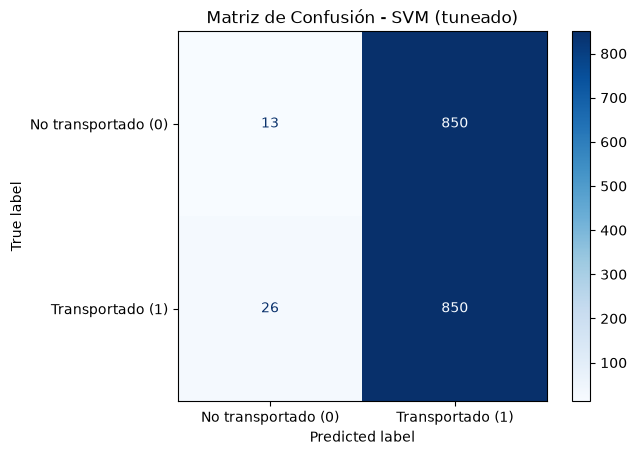

In [45]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

param_dist_svm = {
    'C': loguniform(0.1, 20),        # bajamos el techo de 100 a 20
    'kernel': ['rbf', 'linear'],
    'gamma': loguniform(0.001, 0.5)  # bajamos el techo de 1 a 0.5
}

svm_base = SVC(random_state=42, max_iter=5000)  # <-- clave: limita iteraciones

random_search_svm = RandomizedSearchCV(
    estimator=svm_base,
    param_distributions=param_dist_svm,
    n_iter=15,       # de 20 a 15
    scoring='recall',
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=3
)

print("Iniciando Randomized Search para SVM...")
random_search_svm.fit(X_train, y_train)

print(f"\nMejores hiperparámetros encontrados para maximizar Recall:")
print(random_search_svm.best_params_)
print(f"Mejor Recall en CV: {random_search_svm.best_score_:.4f}")

best_svm_model = random_search_svm.best_estimator_
y_pred_best_svm = best_svm_model.predict(X_test)

evaluar_spaceship_model(y_test, y_pred_best_svm, "SVM (tuneado)")

Iniciando Randomized Search para SVM...
Fitting 3 folds for each of 15 candidates, totalling 45 fits


/opt/conda/lib/python3.13/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/lib/python3.13/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/lib/python3.13/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/lib/python3.13/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/lib/python3.13/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider


Mejores hiperparámetros encontrados para maximizar Recall:
{'C': np.float64(2.5002240473339543), 'gamma': np.float64(0.0028856223618597358), 'kernel': 'rbf'}
Mejor Recall en CV: 0.7280
--- Evaluación de: SVM (tuneado) ---
Métrica Principal (Criterio de decisión):
 * Recall:      0.7546

Métrica Secundaria (Filtro de calidad):
 * F1-Score:    0.7524

Métricas de Referencia / Contexto:
 * Accuracy:    0.7499
 * Precision:   0.7503
 * Specificity: 0.7451

Generando Matriz de Confusión...


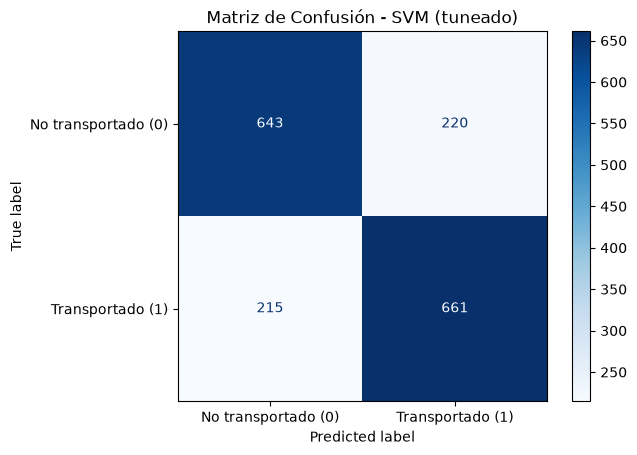

In [46]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

param_dist_svm = {
    'C': loguniform(0.1, 20),        # bajamos el techo de 100 a 20
    'kernel': ['rbf', 'linear'],
    'gamma': loguniform(0.001, 0.5)  # bajamos el techo de 1 a 0.5
}

svm_base = SVC(random_state=42, max_iter=5000)  # <-- clave: limita iteraciones

random_search_svm = RandomizedSearchCV(
    estimator=svm_base,
    param_distributions=param_dist_svm,
    n_iter=15,       # de 20 a 15
    scoring='f1',
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=3
)

print("Iniciando Randomized Search para SVM...")
random_search_svm.fit(X_train, y_train)

print(f"\nMejores hiperparámetros encontrados para maximizar Recall:")
print(random_search_svm.best_params_)
print(f"Mejor Recall en CV: {random_search_svm.best_score_:.4f}")

best_svm_model = random_search_svm.best_estimator_
y_pred_best_svm = best_svm_model.predict(X_test)

evaluar_spaceship_model(y_test, y_pred_best_svm, "SVM (tuneado)")

#### Análisis

En un principio parece que el modelo ya no clasifica; el cambio drástico ocurre porque optimizar el modelo enfocándose únicamente en el Recall permite que el algoritmo encuentre un atajo matemático y haga trampa al predecir la clase positiva para casi todas las instancias (como se observa claramente en la matriz de confusión degenerada primero), lo que eleva el Recall al máximo pero destruye por completo el Accuracy y la especificidad. Al cambiar la métrica de búsqueda al F1-Score, obligamos al modelo a buscar un equilibrio real penalizando tanto los falsos positivos como los falsos negativos, lo que da como resultado un clasificador que efectivamente aprende a separar las clases y presenta métricas mucho más saludables (evidenciado en la segunda matriz de confusión). Sin embargo, incluso después de que esta corrección hace que el SVM sea verdaderamente utilizable (alcanzando métricas cercanas a 0.75), el cambio no es recomendable porque el modelo XGBoost original del equipo sigue siendo superior; como demuestra el gráfico comparativo de la evaluación final, el XGBoost mantiene un F1-score más alto (0.807), mejor exactitud general (0.783) y un Recall bastante robusto (0.899) sin sacrificar severamente la precisión, consolidándose como la opción más confiable y equilibrada para llevar a producción.

### Roberd Meza Sainz (MLPC)

In [47]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV

param_dist_mlp = {
    'hidden_layer_sizes': [(32,), (64,), (32, 16), (64, 32)],
    'alpha': [0.0001, 0.001, 0.002 , 0.01],
    'learning_rate_init': [0.001, 0.01, 0.02]
}

mlp_base = MLPClassifier(max_iter=500, early_stopping=True, random_state=42)

random_search_mlp = RandomizedSearchCV(
    estimator=mlp_base,
    param_distributions=param_dist_mlp,
    n_iter=20,
    scoring='recall',
    cv=cv_strategy,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search_mlp.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(random_search_mlp.best_params_)
print(f"Mejor recall en CV: {random_search_mlp.best_score_:.4f}")

best_mlp = random_search_mlp.best_estimator_
f1_mlp = cross_val_score(best_mlp, X_train, y_train, cv=cv_strategy, scoring='f1', n_jobs=-1)
precision_mlp = cross_val_score(best_mlp, X_train, y_train, cv=cv_strategy, scoring='precision', n_jobs=-1)

print(f"F1 promedio en CV: {f1_mlp.mean():.4f} (+/- {f1_mlp.std():.4f})")
print(f"Precision promedio en CV: {precision_mlp.mean():.4f} (+/- {precision_mlp.std():.4f})")



Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores hiperparámetros:
{'learning_rate_init': 0.01, 'hidden_layer_sizes': (32,), 'alpha': 0.001}
Mejor recall en CV: 0.8272
F1 promedio en CV: 0.7722 (+/- 0.0121)
Precision promedio en CV: 0.7257 (+/- 0.0323)


--- Evaluación de: MLP  ---
Métrica Principal (Criterio de decisión):
 * Recall:      0.7763

Métrica Secundaria (Filtro de calidad):
 * F1-Score:    0.7740

Métricas de Referencia / Contexto:
 * Accuracy:    0.7717
 * Precision:   0.7719
 * Specificity: 0.7671

Generando Matriz de Confusión...


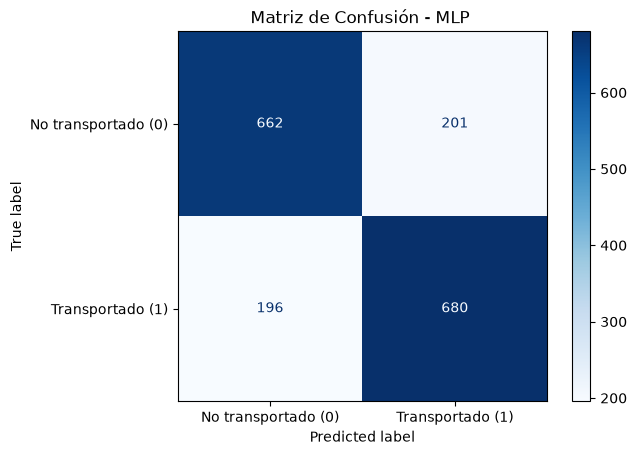

In [48]:
mlp_final = MLPClassifier(
    hidden_layer_sizes=(32,),
    alpha=0.001,
    learning_rate_init=0.01,
    max_iter=500,
    early_stopping=True,
    random_state=42
)

mlp_final.fit(X_train, y_train)
y_pred_mlp = mlp_final.predict(X_test)

evaluar_spaceship_model(y_test, y_pred_mlp, "MLP ")

--- Evaluación de: XGBoost tuneado en equipo ---
Métrica Principal (Criterio de decisión):
 * Recall:      0.8995

Métrica Secundaria (Filtro de calidad):
 * F1-Score:    0.8070

Métricas de Referencia / Contexto:
 * Accuracy:    0.7832
 * Precision:   0.7317
 * Specificity: 0.6651

Generando Matriz de Confusión...


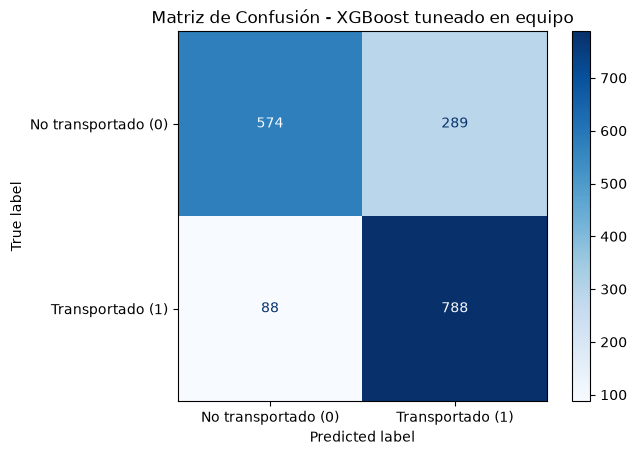

In [49]:
xgb_final = XGBClassifier(
    n_estimators=100,
    max_depth=2,
    learning_rate=0.08,
    scale_pos_weight=2,
    min_child_weight=1,
    subsample=0.8,
    random_state=42,
    eval_metric='logloss'
)
xgb_final.fit(X_train, y_train)
y_pred_xgb_final = xgb_final.predict(X_test)

evaluar_spaceship_model(y_test, y_pred_xgb_final, "XGBoost tuneado en equipo")

| Métrica | XGBoost (equipo) | MLP (individual) | Diferencia |
| :--- | :---: | :---: | :--- |
| **Recall** | 0.8995 | 0.7763 | +12.3% XGBoost |
| **Precision** | 0.7317 | 0.7719 | +4.0% MLP |
| **F1-score** | 0.8070 | 0.7740 | +3.3% XGBoost |
| **Accuracy** | 0.7832 | 0.7717 | +1.2% XGBoost |


***Interpretación***

El modelo XGBoost tuneado por el equipo mantiene un desempeño consistente entre validación cruzada y test (recall de 0.9038 en CV vs 0.8995 en test), mientras que el MLP muestra una caída más notoria (0.8272 en CV vs 0.7763 en test), confirmando la mayor inestabilidad de este último ya observada durante el tuning (desviación estándar de precision considerablemente más alta en CV). En la métrica prioritaria del proyecto, recall, el XGBoost supera al MLP por más de 12%. El MLP obtiene una precision ligeramente mayor, pero ese trade-off no compensa la pérdida de recall dado que los falsos negativos son el error a minimizar en este problema.

No cambiaría la decisión del equipo ya que el MLP no logró igualar o superar al XGBoost en la métrica que define el éxito del proyecto.

### Santiago Serrano Montalvo (KNN)

In [50]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

amplitudes = X_train.max() - X_train.min()
print(f"Amplitud de columna — mayor: {amplitudes.max():.0f} | menor: {amplitudes.min():.0f}")

# Sin escalar, como punto de partida.
knn_crudo = KNeighborsClassifier(n_neighbors=11).fit(X_train, y_train)
y_pred_knn_crudo = knn_crudo.predict(X_test)

# El escalado va DENTRO del pipeline para que se ajuste sólo con el train de cada fold
pipe_knn = Pipeline([
    ("escalar", StandardScaler()),
    ("knn", KNeighborsClassifier()),
])

param_grid_knn = {
    "knn__n_neighbors": [5, 11, 21, 31, 51, 75],  # cuántos vecinos votan
    "knn__weights": ["uniform", "distance"],      # si el más cercano pesa más
    "knn__p": [1, 2],                             # 1 = Manhattan, 2 = Euclidiana
}

# GridSearch y no Randomized: son 24 combinaciones y cabe probarlas todas.
grid_knn = GridSearchCV(
    pipe_knn, param_grid_knn, scoring="recall", cv=cv_strategy, n_jobs=-1
).fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_knn.best_params_)
print(f"Mejor recall en CV: {grid_knn.best_score_:.4f}")

knn_final = grid_knn.best_estimator_
y_pred_knn = knn_final.predict(X_test)

Amplitud de columna — mayor: 1893 | menor: 1
Mejores hiperparámetros: {'knn__n_neighbors': 11, 'knn__p': 1, 'knn__weights': 'uniform'}
Mejor recall en CV: 0.7419


In [51]:
from sklearn.metrics import recall_score

# El modelo del equipo lleva scale_pos_weight=2 y KNN no tiene ese parámetro,así que compararlos en su umbral por defecto compara dos puntos de operación distintos.
proba_knn = knn_final.predict_proba(X_test)[:, 1]
recall_equipo = recall_score(y_test, y_pred_tuned)
umbral = max(u for u in np.unique(proba_knn)
             if recall_score(y_test, (proba_knn >= u).astype(int)) >= recall_equipo)
y_pred_knn_igual = (proba_knn >= umbral).astype(int)

pd.DataFrame([
    calcular_metricas(y_test, y_pred_knn_crudo, "KNN sin escalar"),
    calcular_metricas(y_test, y_pred_knn, "KNN escalado + GridSearch"),
    calcular_metricas(y_test, y_pred_knn_igual, f"KNN al recall del equipo (umbral {umbral:.2f})"),
    calcular_metricas(y_test, y_pred_tuned, "Equipo (XGBoost tuneado)"),
]).set_index("Modelo").round(4)

,Accuracy,Precision,Recall,F1-score,Specificity,FN,FP
Modelo,,,,,,,
KNN sin escalar,0.7142,0.7191,0.7100,0.7145,0.7184,254,243
KNN escalado + GridSearch,0.7861,0.8066,0.7568,0.7809,0.8158,213,159
KNN al recall del equipo (umbral 0.27),0.7039,0.6390,0.9475,0.7632,0.4565,46,469
Equipo (XGBoost tuneado),0.7832,0.7317,0.8995,0.8070,0.6651,88,289


#### Conclusión: ¿cambiaría la decisión del equipo?

**No.**

El escalado sí ayudó a mejorar los resultados de KNN, especialmente en recall y specificity. Sin embargo, el recall sigue siendo menor que el de XGBoost, que es la métrica más importante para el equipo.

Cuando se baja el umbral de KNN, el recall mejora, pero también aumentan mucho los falsos positivos y baja el desempeño general del modelo. Por esta razón, no sería conveniente cambiar la decisión.

También se encontró que el `RobustScaler` no se aplicó correctamente en el primer avance. Aunque esto no afectó mucho a los modelos de árboles, sí cambió los resultados de KNN.

Por lo tanto, **XGBoost seguiría siendo la mejor opción para este caso**, pero sería importante corregir el escalado para futuros análisis.


### Sofia Valeria Ramirez Moreno (Naive Bayes)

Mejores hiperparámetros: {'alpha': 0.01, 'binarize': 1.0, 'fit_prior': True}
Recall promedio en CV: 0.6728
--- Evaluación de: Naive Bayes (BernoulliNB) ---
Métrica Principal (Criterio de decisión):
 * Recall:      0.6564

Métrica Secundaria (Filtro de calidad):
 * F1-Score:    0.7156

Métricas de Referencia / Contexto:
 * Accuracy:    0.7372
 * Precision:   0.7866
 * Specificity: 0.8192

Generando Matriz de Confusión...


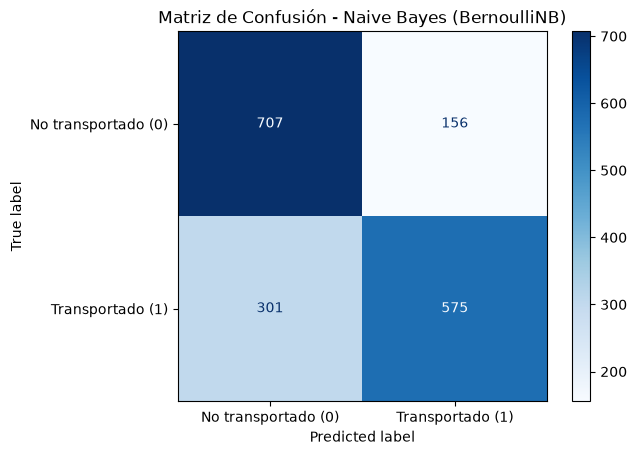

In [52]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import GridSearchCV

param_grid_nb = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 2.0],
    'binarize': [0.0, 0.5, 1.0, 2.0],
    'fit_prior': [True, False]
}

grid_nb = GridSearchCV(
    BernoulliNB(),
    param_grid=param_grid_nb,
    scoring='recall',
    cv=cv_strategy,
    n_jobs=-1
)
grid_nb.fit(X_train, y_train)
y_pred_nb = grid_nb.predict(X_test)

print("Mejores hiperparámetros:", grid_nb.best_params_)
print(f"Recall promedio en CV: {grid_nb.best_score_:.4f}")

evaluar_spaceship_model(y_test, y_pred_nb, "Naive Bayes (BernoulliNB)")

¿Cambiarías la decisión del equipo? No, es el peor de todos los modelos evaluados en el proyecto.

Con 301 Falsos Negativos más del triple que el modelo final del equipo (88) Naive Bayes queda muy lejos del criterio de negocio prioritario. La razón es estructural: el supuesto central del modelo (independencia condicional entre variables dada la clase) es claramente falso en este dataset  las variables de gasto están correlacionadas entre sí y con CryoSleep (un pasajero en CryoSleep no puede gastar en nada), y ese tipo de dependencia es justo lo que Naive Bayes no puede capturar.

## 5. Exportar modelo y submission

- Exporta el modelo final con joblib o pickle.
- Carga el test.csv de Kaggle, aplica el mismo pipeline de preprocesamiento del avance 1 y genera el archivo de submission en el formato requerido (PassengerId, Transported).
- Verifica que el archivo tiene el shape correcto y que Transported es booleano (True/False).

In [53]:
df_train_raw = pd.read_csv('data/train.csv')
df_train_raw[['Cabin_Deck', 'Cabin_Num', 'Cabin_Side']] = df_train_raw['Cabin'].str.split('/', expand=True)
df_train_raw["Group"] = df_train_raw["PassengerId"].str.split("_").str[0]

spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

gasto_conocido = df_train_raw[spend_cols].sum(axis=1, skipna=True) > 0
mask_cryo_missing = df_train_raw["CryoSleep"].isna()
df_train_raw.loc[mask_cryo_missing & gasto_conocido, "CryoSleep"] = False
df_train_raw["CryoSleep"] = df_train_raw["CryoSleep"].fillna(df_train_raw["CryoSleep"].mode()[0]).astype(bool)

for col in spend_cols:
    mask = df_train_raw[col].isna() & (df_train_raw["CryoSleep"] == True)
    df_train_raw.loc[mask, col] = 0

df_train_raw["Cabin_Deck"] = df_train_raw["Cabin_Deck"].replace("T", "D")
df_train_raw["Cabin_Num"] = pd.to_numeric(df_train_raw["Cabin_Num"], errors="coerce")

stats = dict(
    moda_cryosleep=df_train_raw["CryoSleep"].mode()[0],
    medianas_spend={col: df_train_raw[col].median() for col in spend_cols},
    mediana_age=df_train_raw["Age"].median(),
    homeplanet_por_grupo=(
        df_train_raw.dropna(subset=["HomePlanet"])
        .groupby("Group")["HomePlanet"]
        .agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
    ),
    moda_homeplanet=df_train_raw["HomePlanet"].mode()[0],
    moda_destination=df_train_raw["Destination"].mode()[0],
    moda_cabin_side=df_train_raw["Cabin_Side"].mode()[0],
    moda_cabin_deck=df_train_raw["Cabin_Deck"].mode()[0],
    mediana_cabin_num_por_deck=df_train_raw.groupby("Cabin_Deck")["Cabin_Num"].median(),
    mediana_cabin_num_global=df_train_raw["Cabin_Num"].median(),
)

In [54]:
def preprocesar(df_raw, stats):
    df = df_raw.copy()

    df[['Cabin_Deck', 'Cabin_Num', 'Cabin_Side']] = df['Cabin'].str.split('/', expand=True)
    df["Group"] = df["PassengerId"].str.split("_").str[0]
    df["GroupSize"] = df.groupby("Group")["Group"].transform("count")
    df["IsAlone"] = (df["GroupSize"] == 1).astype(int)

    passenger_ids = df["PassengerId"]
    df.drop(columns=["PassengerId", "Name", "Cabin", "VIP"], inplace=True)

    spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
    df["TotalSpent"] = df[spend_cols].sum(axis=1, skipna=True)
    df["HasSpent"] = (df["TotalSpent"] > 0).astype(int)
    df["IsChild"] = (df["Age"] < 15).astype(int)

    gasto_conocido = df[spend_cols].sum(axis=1, skipna=True) > 0
    mask_cryo_missing = df["CryoSleep"].isna()
    df.loc[mask_cryo_missing & gasto_conocido, "CryoSleep"] = False
    df["CryoSleep"] = df["CryoSleep"].fillna(stats["moda_cryosleep"]).astype(bool)

    for col in spend_cols:
        mask = df[col].isna() & (df["CryoSleep"] == True)
        df.loc[mask, col] = 0
    for col in spend_cols:
        df[col] = df[col].fillna(stats["medianas_spend"][col])

    df["Age"] = df["Age"].fillna(stats["mediana_age"])

    mask_hp_na = df["HomePlanet"].isna()
    df.loc[mask_hp_na, "HomePlanet"] = df.loc[mask_hp_na, "Group"].map(stats["homeplanet_por_grupo"])
    df["HomePlanet"] = df["HomePlanet"].fillna(stats["moda_homeplanet"])
    df["Destination"] = df["Destination"].fillna(stats["moda_destination"])
    df["Cabin_Side"] = df["Cabin_Side"].fillna(stats["moda_cabin_side"])

    df["Cabin_Deck"] = df["Cabin_Deck"].replace("T", "D")
    df["Cabin_Deck"] = df["Cabin_Deck"].fillna(stats["moda_cabin_deck"])

    df["Cabin_Num"] = pd.to_numeric(df["Cabin_Num"], errors="coerce")
    df["Cabin_Num"] = df["Cabin_Num"].fillna(df["Cabin_Deck"].map(stats["mediana_cabin_num_por_deck"]))
    df["Cabin_Num"] = df["Cabin_Num"].fillna(stats["mediana_cabin_num_global"])

    df["TotalSpent"] = df[spend_cols].sum(axis=1)
    df["HasSpent"] = (df["TotalSpent"] > 0).astype(int)
    df["IsChild"] = (df["Age"] < 15).astype(int)

    df.drop(columns="Group", inplace=True)

    df["CryoSleep"] = df["CryoSleep"].astype(int)
    df["Cabin_Side"] = df["Cabin_Side"].map({"P": 0, "S": 1})

    df = pd.get_dummies(df, columns=["HomePlanet", "Destination", "Cabin_Deck"], drop_first=True)
    dummy_cols = df.select_dtypes(include="bool").columns
    df[dummy_cols] = df[dummy_cols].astype(int)

    log_cols = spend_cols + ["TotalSpent"]
    df[[f"{col}_log" for col in log_cols]] = np.log1p(df[log_cols])
    df.drop(columns=log_cols, inplace=True)

    # Sin scaler.transform(): X_train/X_test tampoco quedaron escalados (el RobustScaler
    # del Primer Avance solo transformó una copia, no df_train), así que se mantiene la
    # misma distribución que vio el modelo al entrenar.
    df = df.reindex(columns=X_train.columns, fill_value=0)

    return passenger_ids, df

In [55]:
import joblib

passenger_ids, X_submission = preprocesar(df_test, stats)

y_pred_submission = best_model.predict(X_submission).astype(bool)

submission = pd.DataFrame({
    "PassengerId": passenger_ids,
    "Transported": y_pred_submission
})

submission.to_csv("submission.csv", index=False)
joblib.dump(best_model, "modelo_final_xgboost.pkl")

print(submission.shape)
print(submission.dtypes)
print(submission["Transported"].unique())
submission.head()

(4277, 2)
PassengerId     str
Transported    bool
dtype: object
[ True False]


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


6. Conclusión final del equipo

- ¿Qué aprendieron del comportamiento de los modelos sobre este dataset a lo largo de los tres avances?
- ¿Qué cambiarían en el pipeline de preprocesamiento sabiendo lo que saben ahora?
- ¿Qué esperan mejorar en la siguiente iteración?

A lo largo de los tres avances aprendimos que el techo de desempeño de este dataset (~80% de accuracy, ~83-85% de recall) no dependía tanto del algoritmo elegido como de la información disponible en las variables: Random Forest y XGBoost rindieron de forma casi idéntica en el Segundo Avance, y la exploración individual de hiperparámetros (n_estimators, max_depth, subsample) apenas movió las métricas, salvo `learning_rate`, que dio una mejora pequeña pero real. El Tercer Avance confirmó esto de forma explícita: las curvas de aprendizaje y validación mostraron que el modelo había alcanzado un techo de sesgo, no de varianza ni de falta de datos, así que seguir ajustando la complejidad del árbol (profundidad, número de estimadores) tenía rendimientos marginales decrecientes. El salto real de desempeño (recall de 83.68% a 89.95%) no vino de "aprender mejor" el patrón subyacente, sino de `scale_pos_weight`: redefinir el costo de los errores dentro de la función de pérdida para alinearla con la prioridad de negocio (minimizar falsos negativos), a costa consciente de precision, specificity y accuracy. El componente individual reforzó esta lectura desde otro ángulo: ninguno de los cinco modelos de familia distinta (Regresión Logística, SVM, MLP, KNN, Naive Bayes) logró igualar el recall de XGBoost, lo que sugiere que las relaciones relevantes del dataset (como la interacción entre CryoSleep y las variables de gasto) son más no lineales de lo que un modelo lineal, de distancia o probabilístico ingenuo puede capturar.

Sabiendo lo que sabemos ahora, cambiaríamos varias cosas del pipeline de preprocesamiento. La más importante es un bug que detectamos en la Sección 5: el `RobustScaler` del Primer Avance se ajustó y aplicó sobre una copia (`X`), nunca sobre `df_train` en sí, así que todo el dataset que realmente entrenó y evaluó los modelos en los tres avances quedó sin escalar. A los modelos de árbol no les afectó (son invariantes a escala), pero sí distorsionó los resultados de KNN, y probablemente también los de SVM, MLP y Regresión Logística, que sí son sensibles a la escala de las variables. La causa raíz fue escribir el preprocesamiento como código inline mutando el mismo dataframe en vez de encapsularlo en un pipeline reutilizable (por ejemplo con `ColumnTransformer`), lo que también nos obligó a reconstruir manualmente toda la lógica de imputación para poder procesar `test.csv` en la Sección 5. Con un pipeline explícito, ese bug se habría detectado antes y aplicar el mismo preprocesamiento a datos nuevos habría sido trivial en vez de un ejercicio de reingeniería. También reconsideraríamos haber usado el mismo conjunto de prueba para tomar decisiones de modelo a lo largo de tres avances distintos, lo cual puede introducir un sesgo optimista en las métricas finales, algo que ya habíamos anticipado desde el Segundo Avance.

Para la siguiente iteración esperamos: (1) mover el control del trade-off recall/precision de `scale_pos_weight` a un ajuste explícito del umbral de clasificación sobre `predict_proba`, lo que da control continuo y más interpretable sobre ese balance; (2) corregir el bug de escalado y volver a evaluar los modelos sensibles a escala (KNN, SVM, MLP, Regresión Logística) con las variables correctamente transformadas, ya que sospechamos que su desempeño real está subestimado; (3) profundizar en feature engineering orientado a las interacciones que el diagnóstico de la Sección 1 sugiere que el modelo no está aprovechando del todo, en vez de seguir ajustando hiperparámetros de un modelo que ya toco su techo de sesgo; y (4) explorar un ensamble o stacking entre XGBoost y alguno de los modelos individuales, dado que cada uno mostró un perfil distinto de precision/specificity que podría ser complementario.